Setup and Dataset Extraction

In [ ]:
import os
import gc
import zipfile
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup paths
ZIP_PATH = '/content/MachineLearningCSV.zip'
EXTRACT_PATH = '/content/cicids_data'

# 1. Extraction logic
if os.path.exists(ZIP_PATH):
    print("Unzipping MachineLearningCSV.zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction complete.")
else:
    print(f"Error: {ZIP_PATH} not found. Please upload the zip to /content/")

# 2. Identify the CSV files

csv_files = glob.glob(os.path.join(EXTRACT_PATH, "MachineLearningCVE", "*.csv"))
print(f"Found {len(csv_files)} CSV files for processing.")

Unzipping MachineLearningCSV.zip...
Extraction complete.
Found 8 CSV files for processing.


---------------- 1. Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv-------------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip().replace({'Web Attack  Brute Force': 'Web Attack - Brute Force'})

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Raw Flow Shape: 225,745 Rows | 79 Columns
Post-Sanitization Volume: 223,112 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'DDoS']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

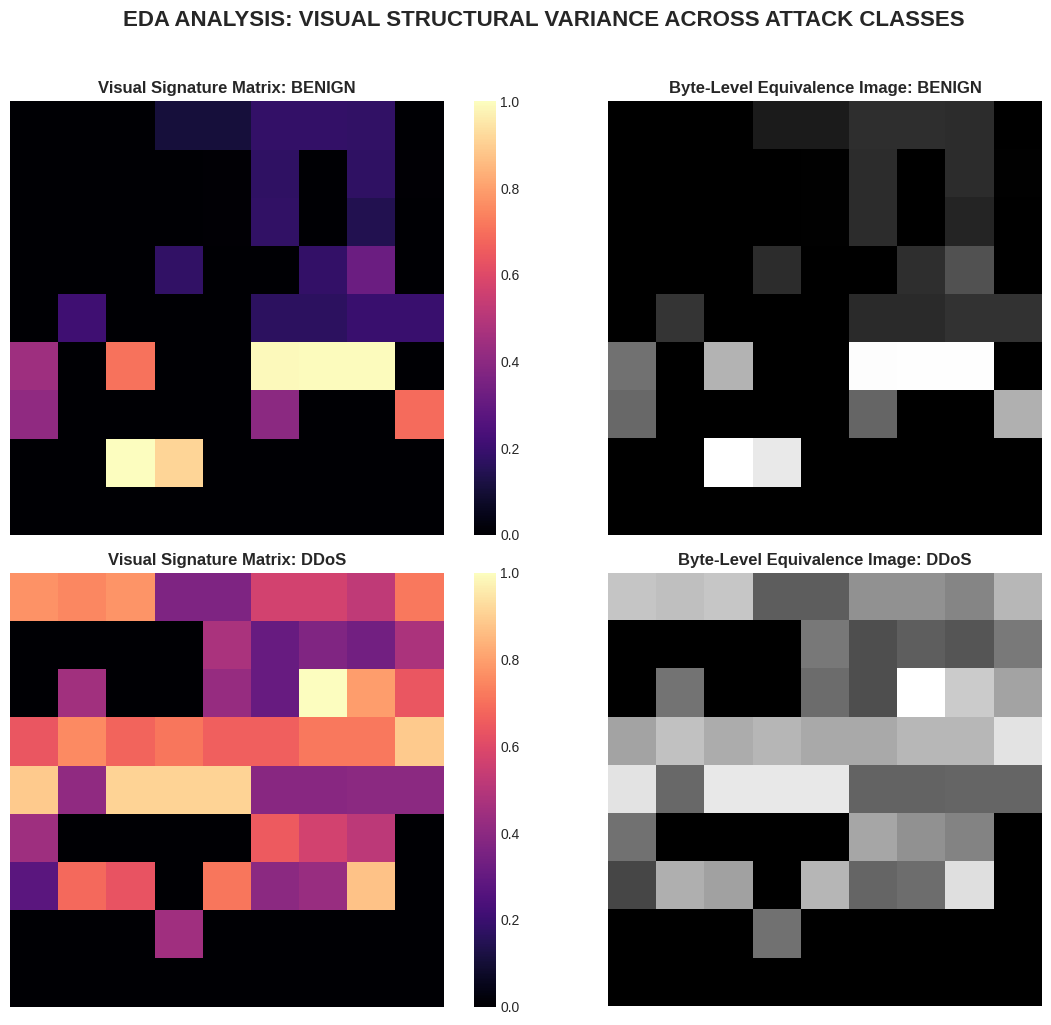

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


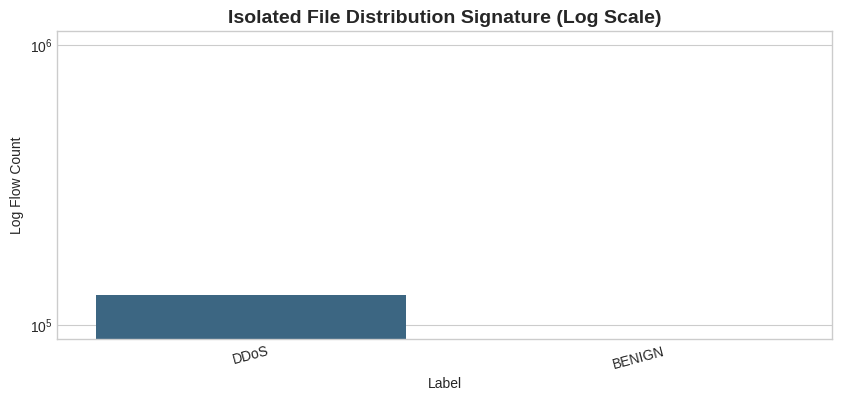

📝 Current Sub-split Frequency Index:
 🔹 DDoS            : 128,016 flows (57.38%)
 🔹 BENIGN          : 95,096 flows (42.62%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("📝 Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

Generating comparative visualization plots...


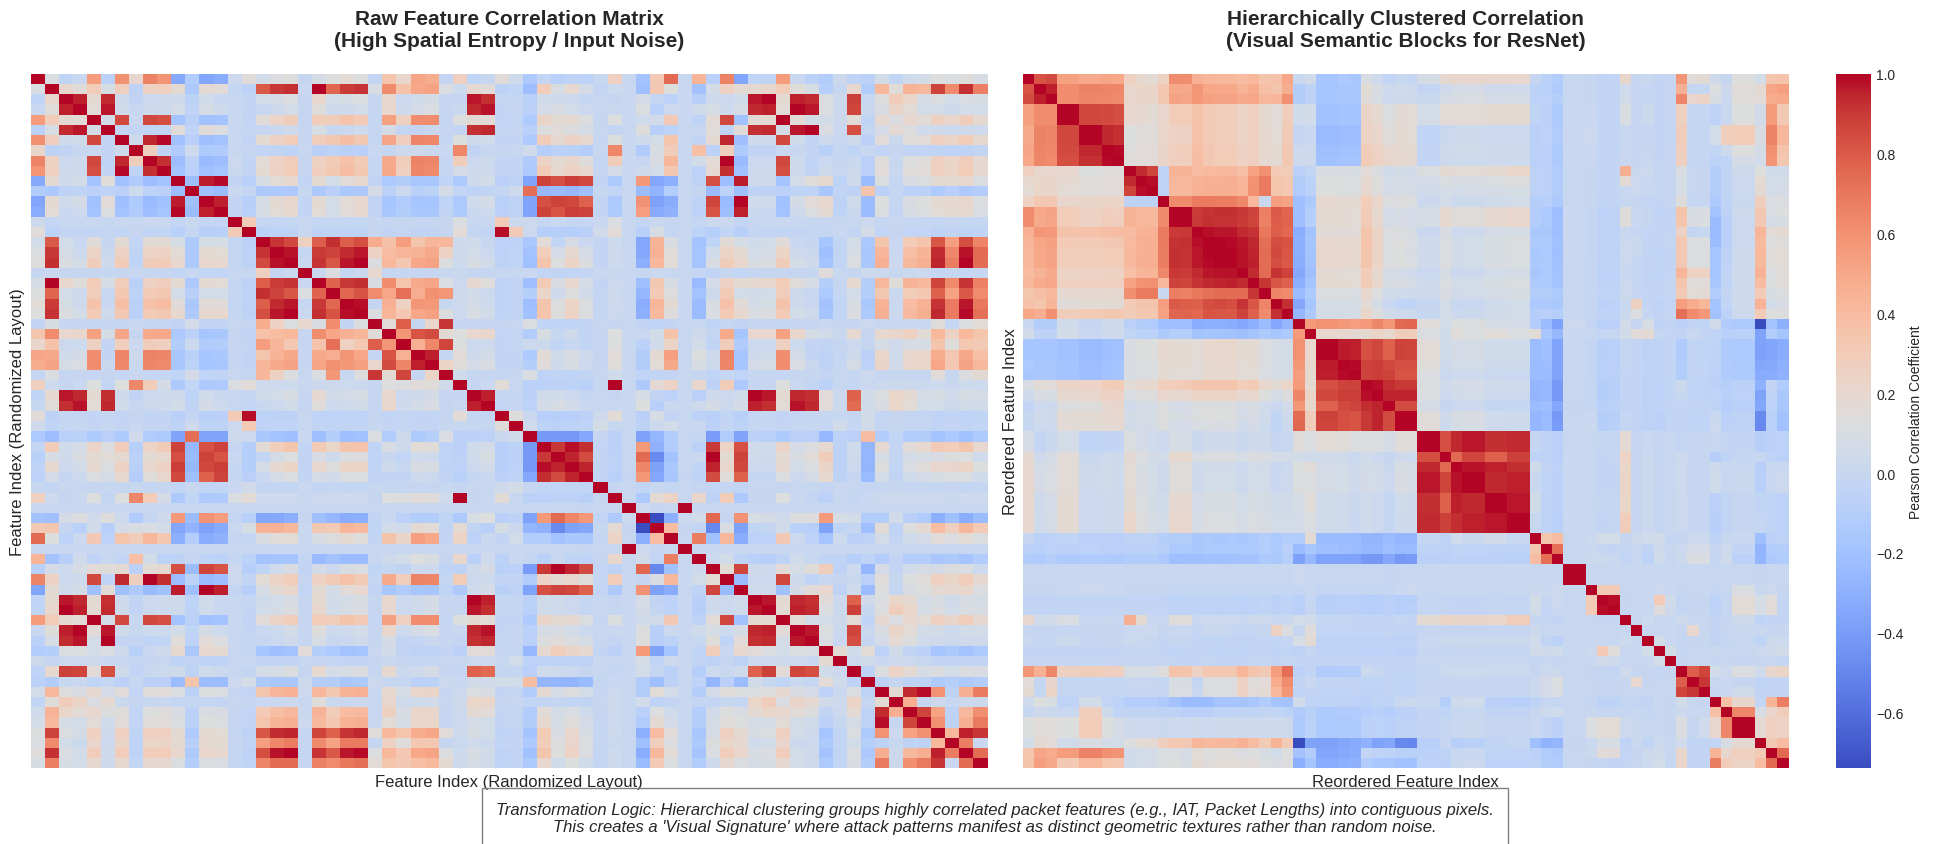

Spatial verification complete. Structured groupings successfully established on the active data slice.


In [ ]:
# --- 6. SPATIAL REORDERING VERIFICATION (DUAL-CORRELATION HEATMAPS) ---
print("Generating comparative visualization plots...")

# Extract correlation matrices directly from active data state dataframes
original_corr = X_filtered.corr().fillna(0)
reordered_corr = X_filtered[ordered_features].corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot A: Left Matrix (Raw Chaos)
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized Layout)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized Layout)", fontsize=12)

# Plot B: Right Matrix (Organized Visual Semantic Blocks)
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Structural Text Explanation Block Injection for Research Paper
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"Spatial verification complete. Structured groupings successfully established on the active data slice.")

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 178,489 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (178,489 samples) for 10 Epochs...


Epoch 1/10: 100%|██████████| 1395/1395 [03:40<00:00,  6.33it/s, loss=0.0002]



📊 [Epoch 1] Train Loss: 0.0092 | Val Acc: 0.9998 | Macro F1: 0.9998
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 1395/1395 [04:31<00:00,  5.13it/s, loss=0.0001]



📊 [Epoch 2] Train Loss: 0.0004 | Val Acc: 0.9996 | Macro F1: 0.9996


...


📊 [Epoch 8] Train Loss: 0.0001 | Val Acc: 0.9998 | Macro F1: 0.9998


Epoch 9/10: 100%|██████████| 1395/1395 [04:26<00:00,  5.22it/s, loss=0.0000]



📊 [Epoch 9] Train Loss: 0.0000 | Val Acc: 0.9998 | Macro F1: 0.9998


Epoch 10/10: 100%|██████████| 1395/1395 [03:57<00:00,  5.86it/s, loss=0.0000]



📊 [Epoch 10] Train Loss: 0.0000 | Val Acc: 0.9998 | Macro F1: 0.9998

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 349/349 [01:02<00:00,  5.56it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.9866%
MACRO PRECISION:   0.9998
MACRO RECALL:      0.9999
MACRO F1-SCORE:    0.9999


,precision,recall,f1-score
BENIGN,0.9997,1.0000,0.9998
DDoS,1.0000,0.9998,0.9999


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...
DEBUG: Could not find a correctly predicted sample for DDoS in the test set.

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


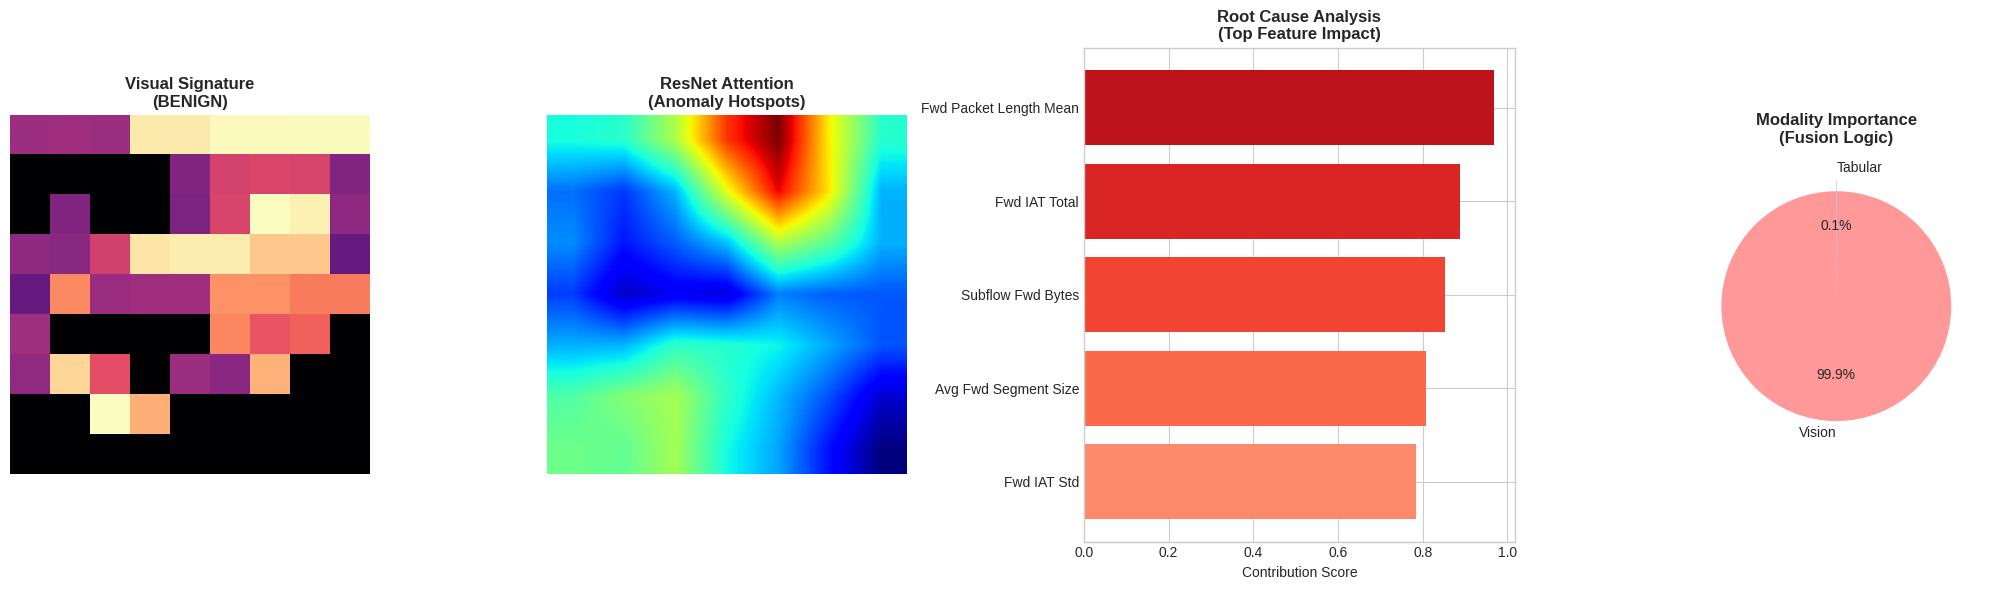

⚠️ No correct prediction found for DDoS in current test sample.


In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    # Iterate through each class to explicitly find one correctly predicted sample
    for class_label_idx, class_name_expected in enumerate(le.classes_):
        if class_name_expected not in class_indices:
            found_sample_for_class = False
            for i in range(len(y_te)): # Search through all test samples
                # Only consider samples that actually belong to this class_name_expected
                if y_te[i] == class_label_idx:
                    t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
                    img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
                    img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

                    pred = torch.argmax(model(t, img), dim=1).item()

                    # If the model correctly predicted this sample's class
                    if pred == class_label_idx:
                        class_indices[class_name_expected] = i
                        found_sample_for_class = True
                        break # Found a representative for this class, move to the next class

            if not found_sample_for_class:
                print(f"DEBUG: Could not find a correctly predicted sample for {class_name_expected} in the test set.")

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")

----------2. Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Raw Flow Shape: 286,467 Rows | 79 Columns
Post-Sanitization Volume: 214,114 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'PortScan']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

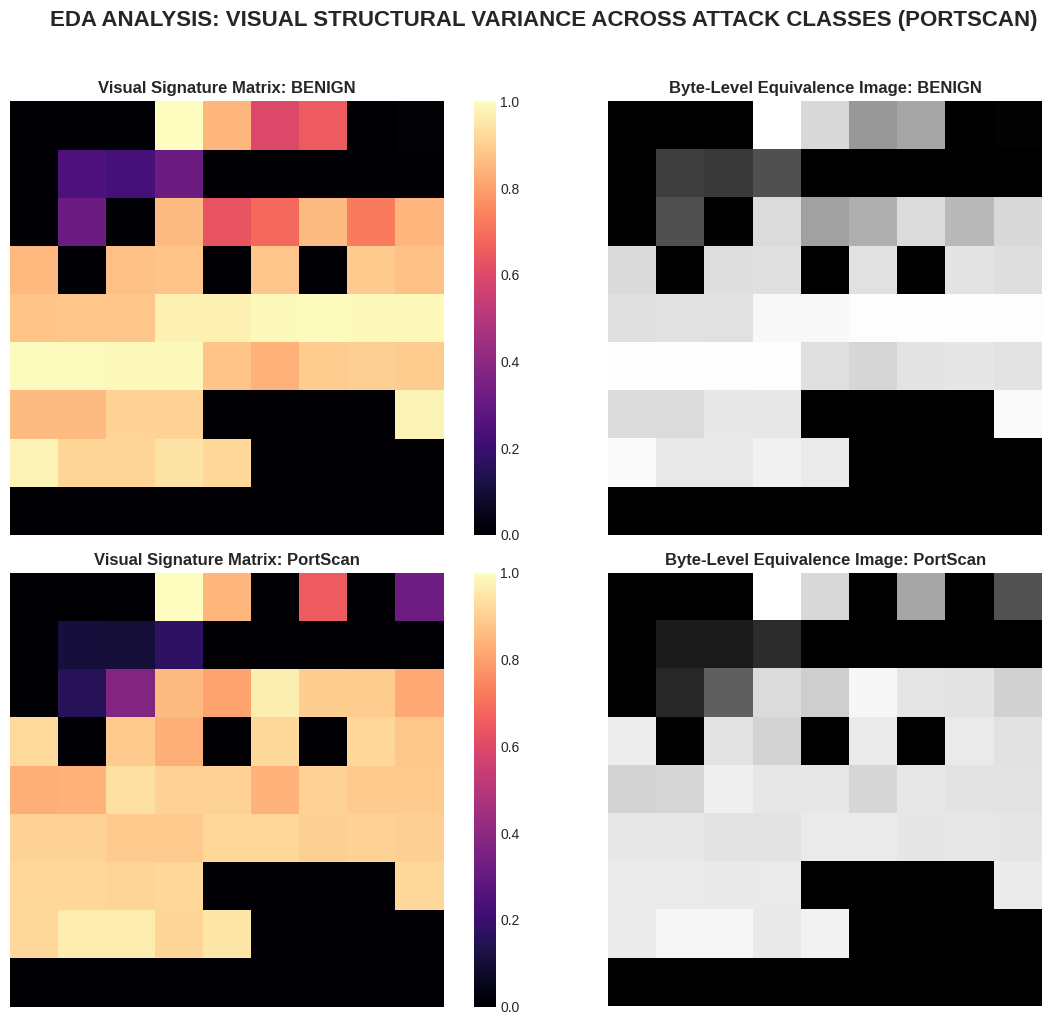

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (PORTSCAN)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


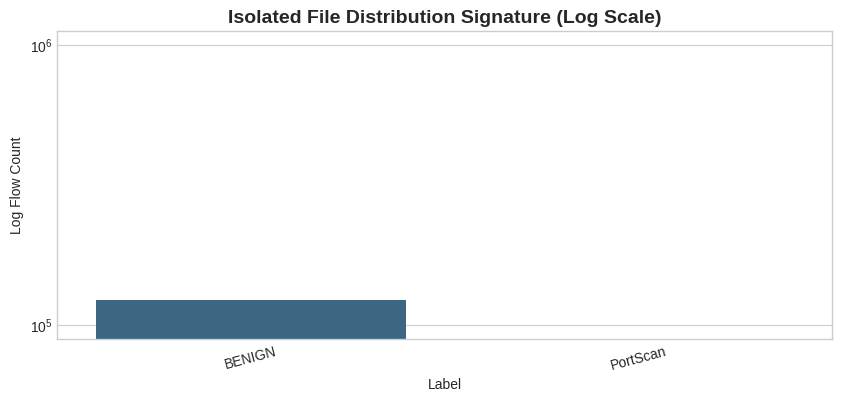

Current Sub-split Frequency Index:
 🔹 BENIGN          : 123,295 flows (57.58%)
 🔹 PortScan        : 90,819 flows (42.42%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

Generating PortScan file correlation matrix transformation graphics...


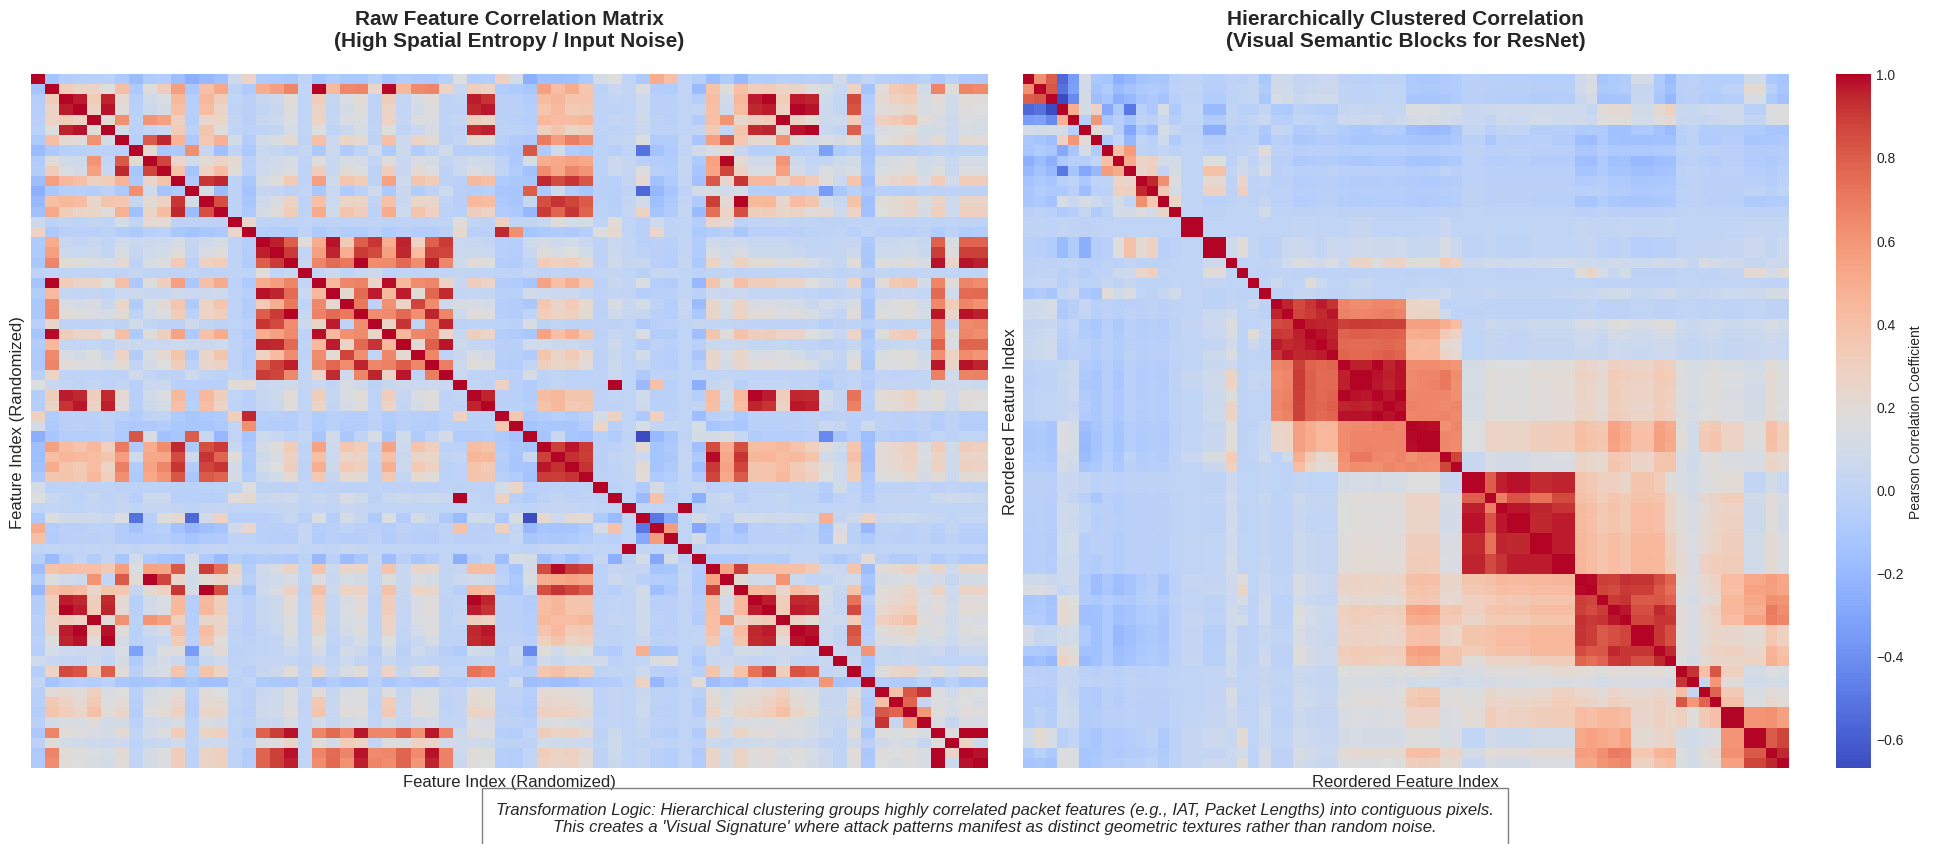

 Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


1261

In [ ]:
print("Generating PortScan file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend metadata caption injection
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(features_to_map.columns) if 'features_to_map' in locals() else len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 171,291 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (171,291 samples) for 10 Epochs...


Epoch 1/10: 100%|██████████| 1339/1339 [03:31<00:00,  6.32it/s, loss=0.0025]



📊 [Epoch 1] Train Loss: 0.0058 | Val Acc: 0.9998 | Macro F1: 0.9998
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 1339/1339 [04:10<00:00,  5.34it/s, loss=0.0001]



📊 [Epoch 2] Train Loss: 0.0007 | Val Acc: 0.9998 | Macro F1: 0.9998
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


...


📊 [Epoch 8] Train Loss: 0.0001 | Val Acc: 0.9999 | Macro F1: 0.9999


Epoch 9/10: 100%|██████████| 1339/1339 [03:58<00:00,  5.61it/s, loss=0.0000]



📊 [Epoch 9] Train Loss: 0.0001 | Val Acc: 0.9999 | Macro F1: 0.9999


Epoch 10/10: 100%|██████████| 1339/1339 [04:00<00:00,  5.56it/s, loss=0.0000]



📊 [Epoch 10] Train Loss: 0.0000 | Val Acc: 0.9999 | Macro F1: 0.9999

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 335/335 [01:03<00:00,  5.24it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.9860%
MACRO PRECISION:   0.9999
MACRO RECALL:      0.9998
MACRO F1-SCORE:    0.9999


,precision,recall,f1-score
BENIGN,0.9998,1.0000,0.9999
PortScan,1.0000,0.9997,0.9998


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


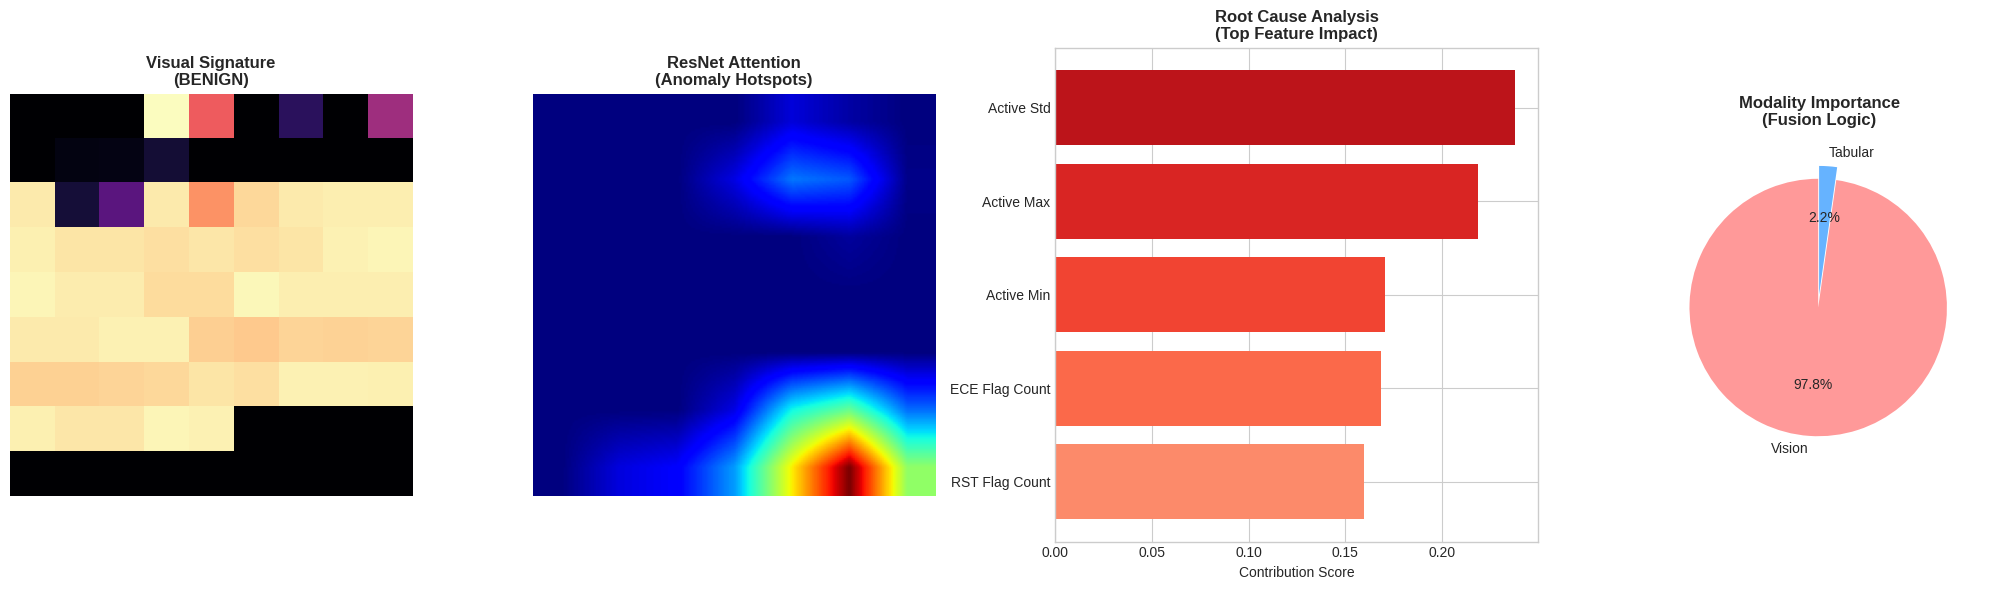


############################################################
# SOC ANALYST INTELLIGENCE: PORTSCAN
############################################################


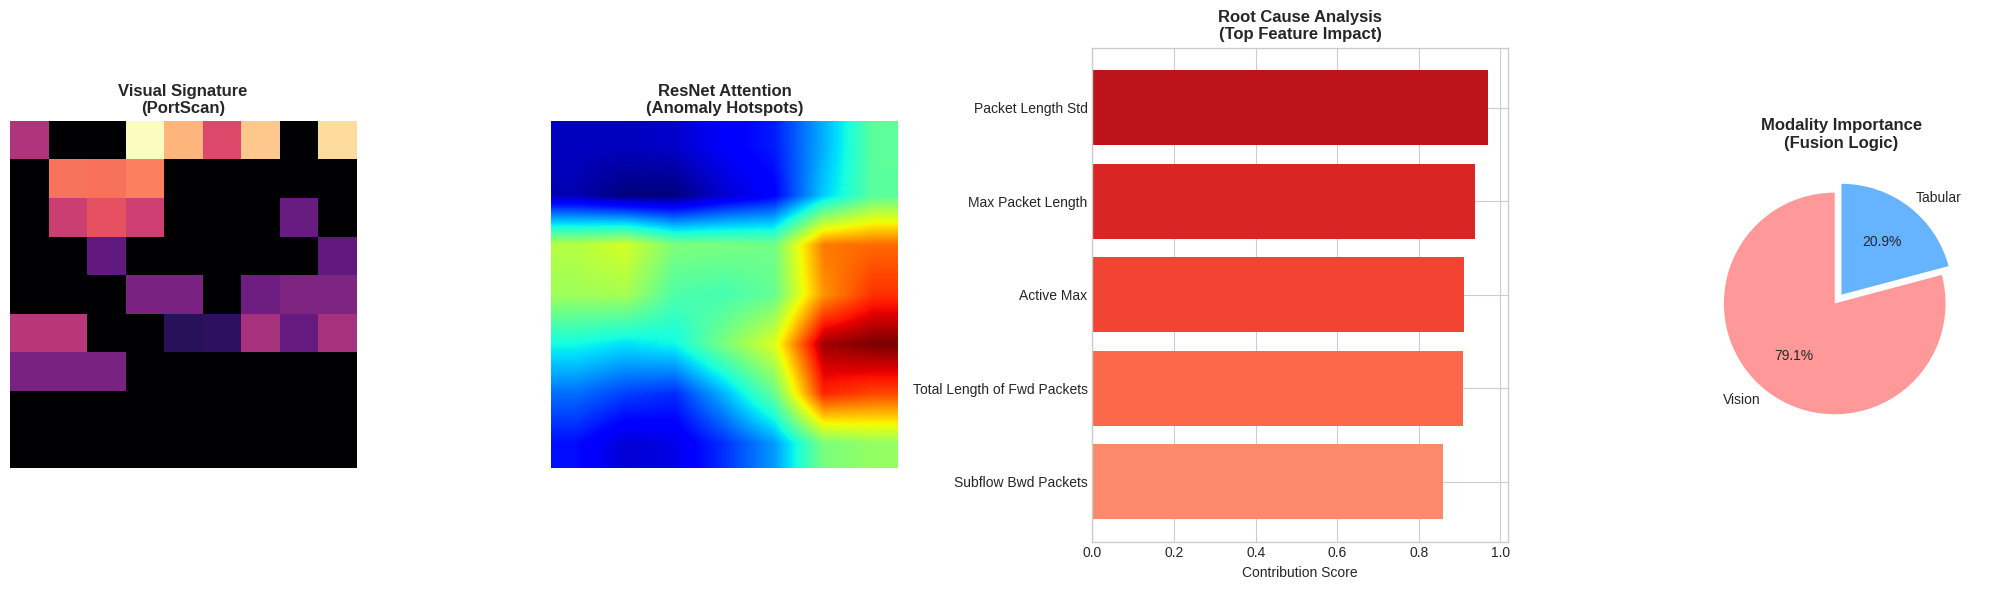

In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")

 ----------3. Friday-WorkingHours-Morning.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Friday-WorkingHours-Morning.pcap_ISCX.csv
Raw Flow Shape: 191,033 Rows | 79 Columns
Post-Sanitization Volume: 184,145 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'Bot']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

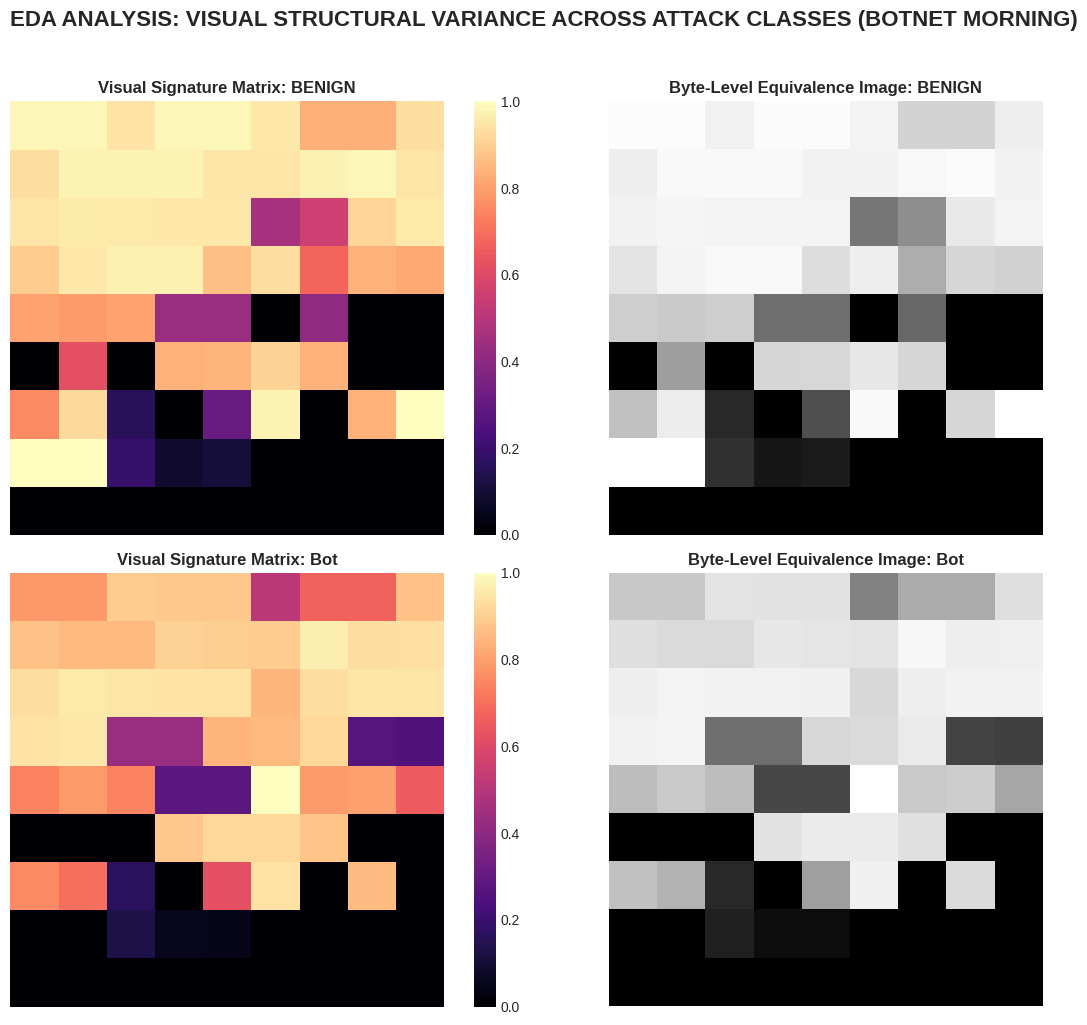

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (BOTNET MORNING)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


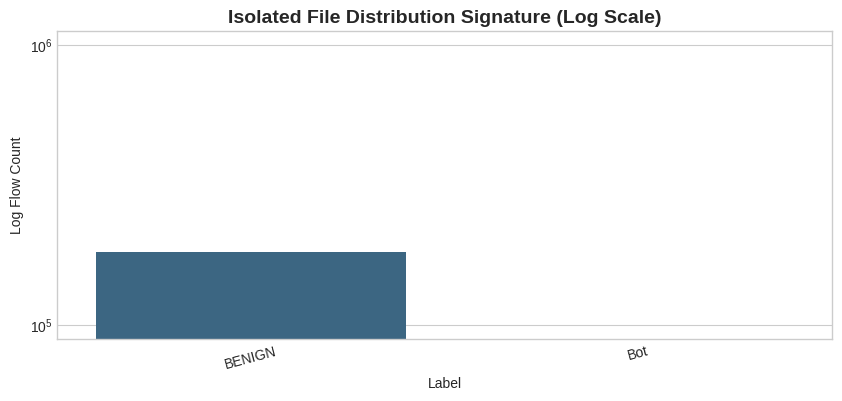

 Current Sub-split Frequency Index:
 🔹 BENIGN          : 182,192 flows (98.94%)
 🔹 Bot             : 1,953 flows (1.06%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Morning file correlation matrix transformation graphics...


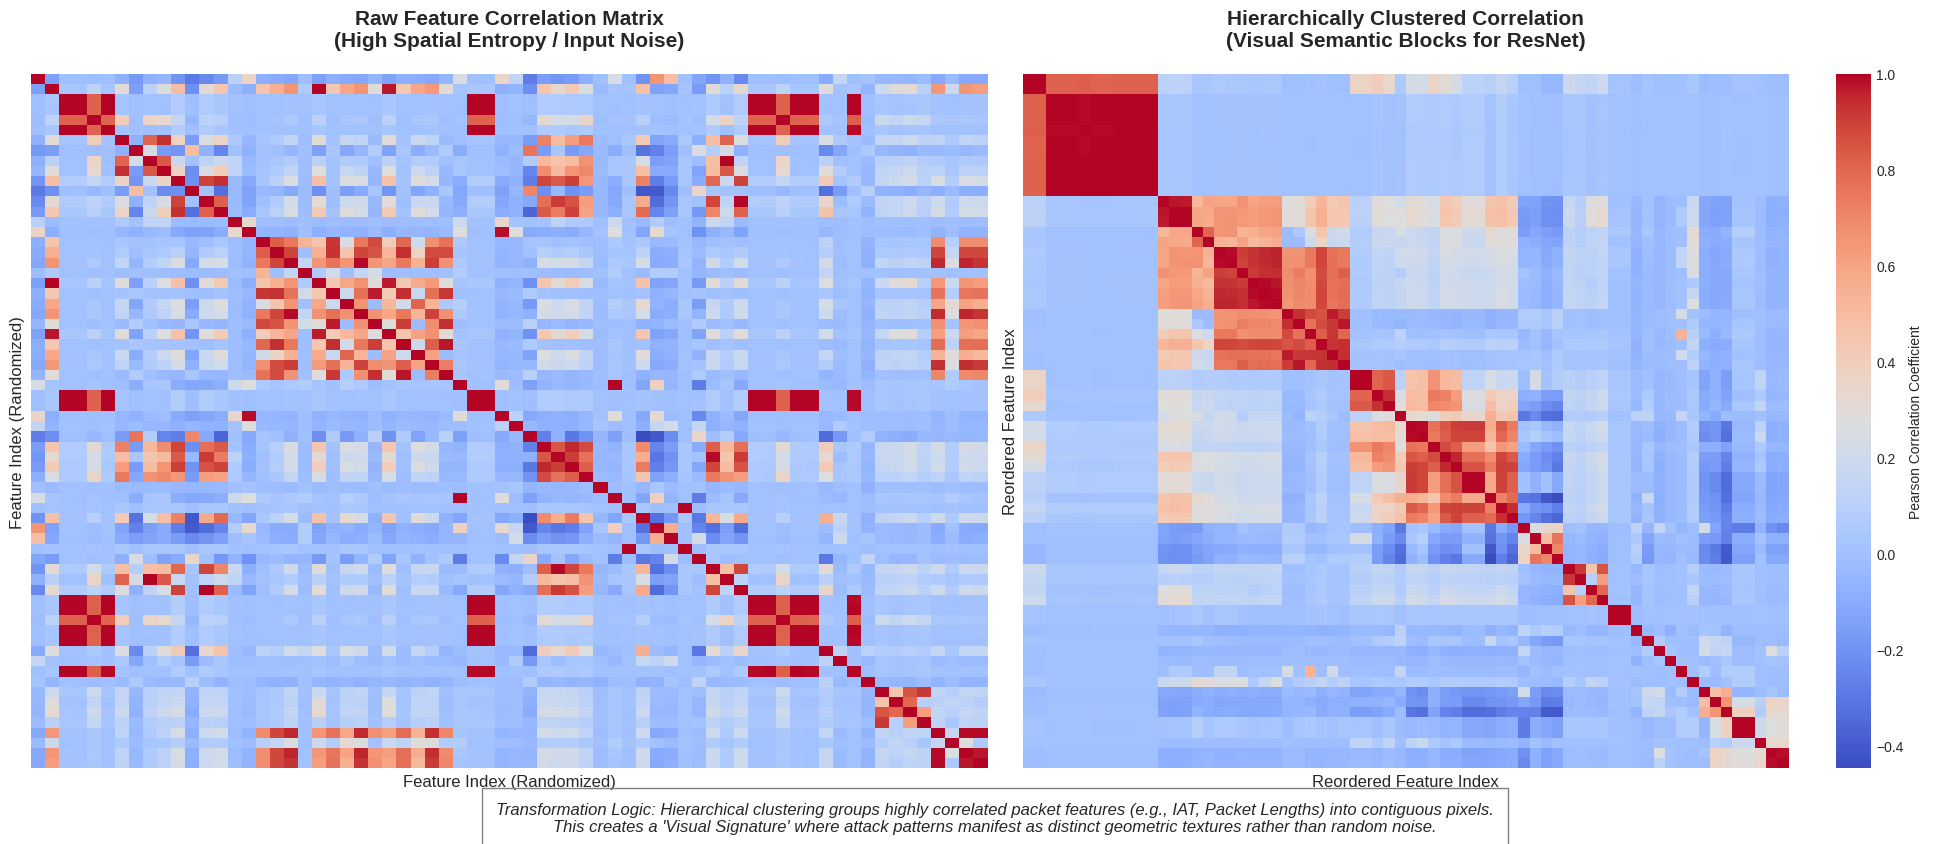

 Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


39175

In [ ]:
print(" Generating Morning file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 147,316 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (147,316 samples) for 10 Epochs...


Epoch 1/10: 100%|██████████| 1151/1151 [03:07<00:00,  6.14it/s, loss=0.0723]



📊 [Epoch 1] Train Loss: 0.0880 | Val Acc: 0.9794 | Macro F1: 0.7481
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 1151/1151 [03:05<00:00,  6.21it/s, loss=0.0138]



📊 [Epoch 2] Train Loss: 0.0440 | Val Acc: 0.9881 | Macro F1: 0.8163
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


...


📊 [Epoch 8] Train Loss: 0.0081 | Val Acc: 0.9981 | Macro F1: 0.9576
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 9/10: 100%|██████████| 1151/1151 [03:08<00:00,  6.09it/s, loss=0.0030]



📊 [Epoch 9] Train Loss: 0.0058 | Val Acc: 0.9985 | Macro F1: 0.9661
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 10/10: 100%|██████████| 1151/1151 [03:07<00:00,  6.13it/s, loss=0.0002]



📊 [Epoch 10] Train Loss: 0.0046 | Val Acc: 0.9986 | Macro F1: 0.9683
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 288/288 [00:49<00:00,  5.88it/s]


🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.8588%
MACRO PRECISION:   0.9430
MACRO RECALL:      0.9968
MACRO F1-SCORE:    0.9683


,precision,recall,f1-score
BENIGN,0.9999,0.9986,0.9993
Bot,0.8861,0.9949,0.9373


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


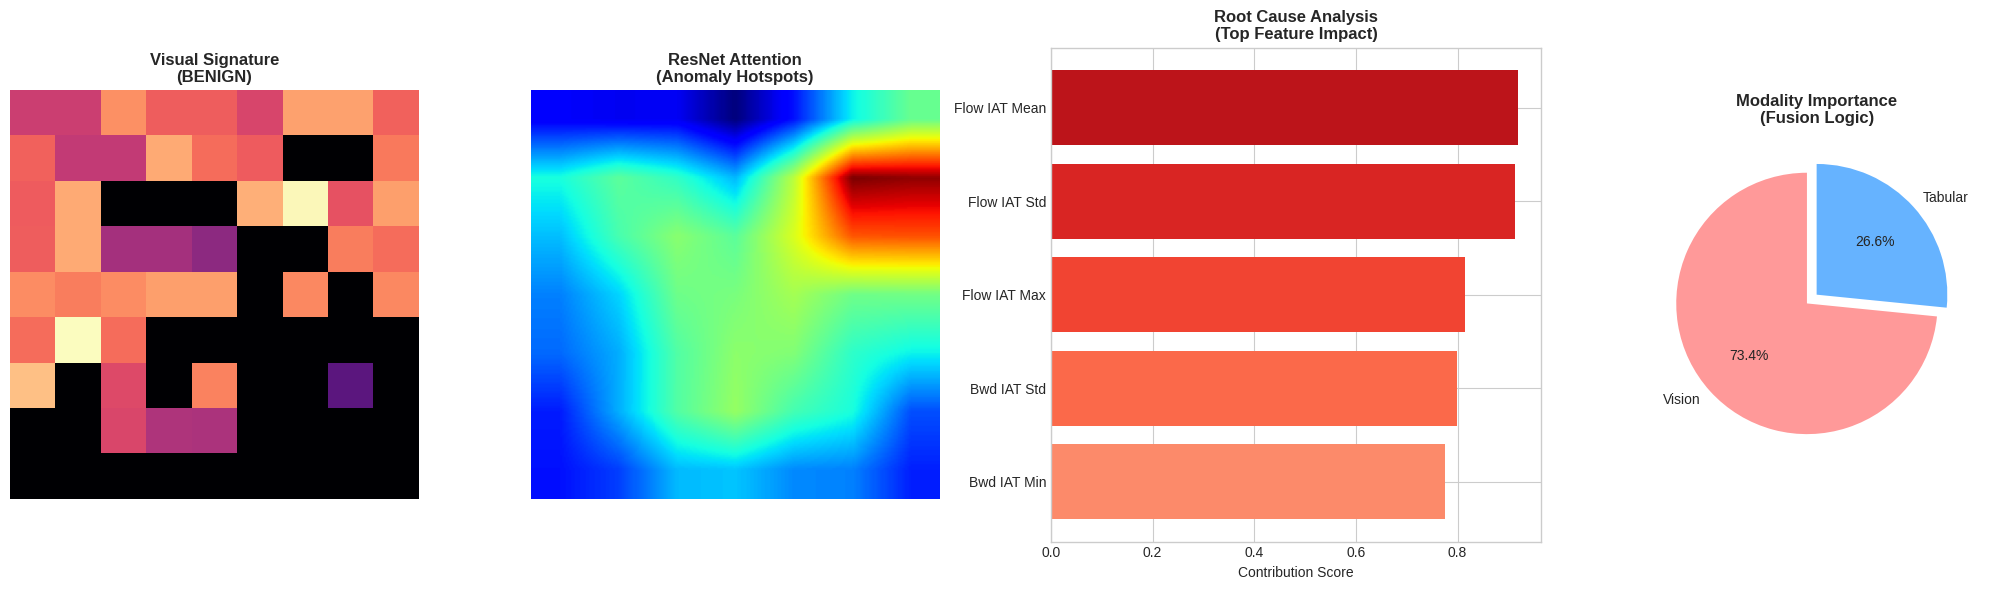

⚠️ No correct prediction found for Bot in current test sample.


In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")

----------4. Monday-WorkingHours.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Monday-WorkingHours.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Monday-WorkingHours.pcap_ISCX.csv
Raw Flow Shape: 529,918 Rows | 79 Columns
Post-Sanitization Volume: 502,983 Unique Network Flows
Target Ground Truths Available: ['BENIGN']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

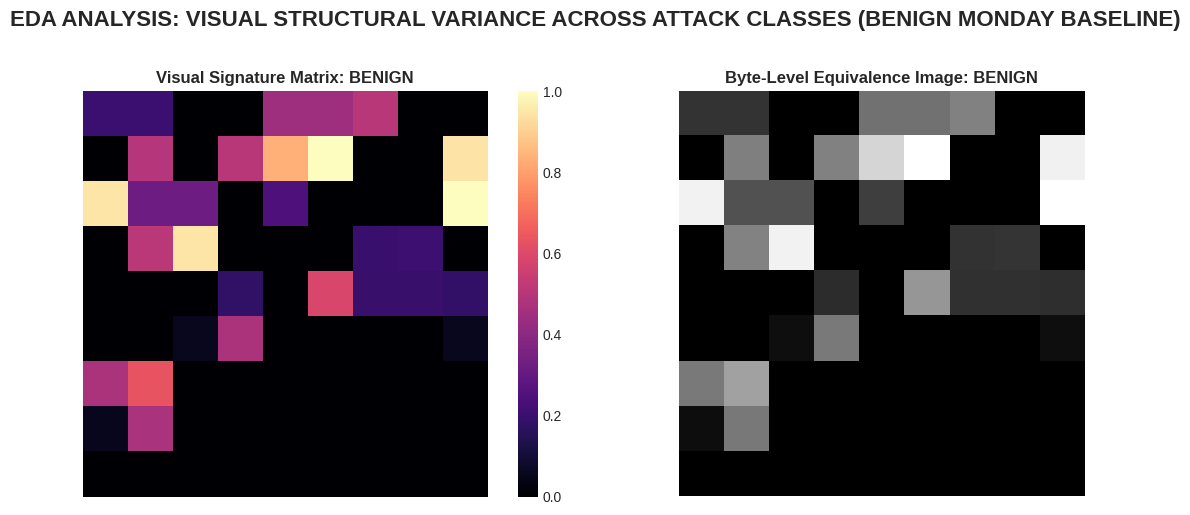

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (BENIGN MONDAY BASELINE)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

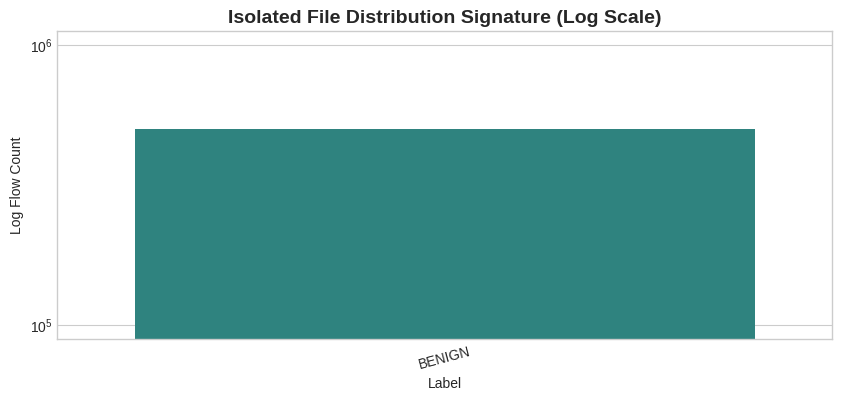

 Current Sub-split Frequency Index:
 🔹 BENIGN          : 502,983 flows (100.00%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Monday Baseline file correlation matrix transformation graphics...


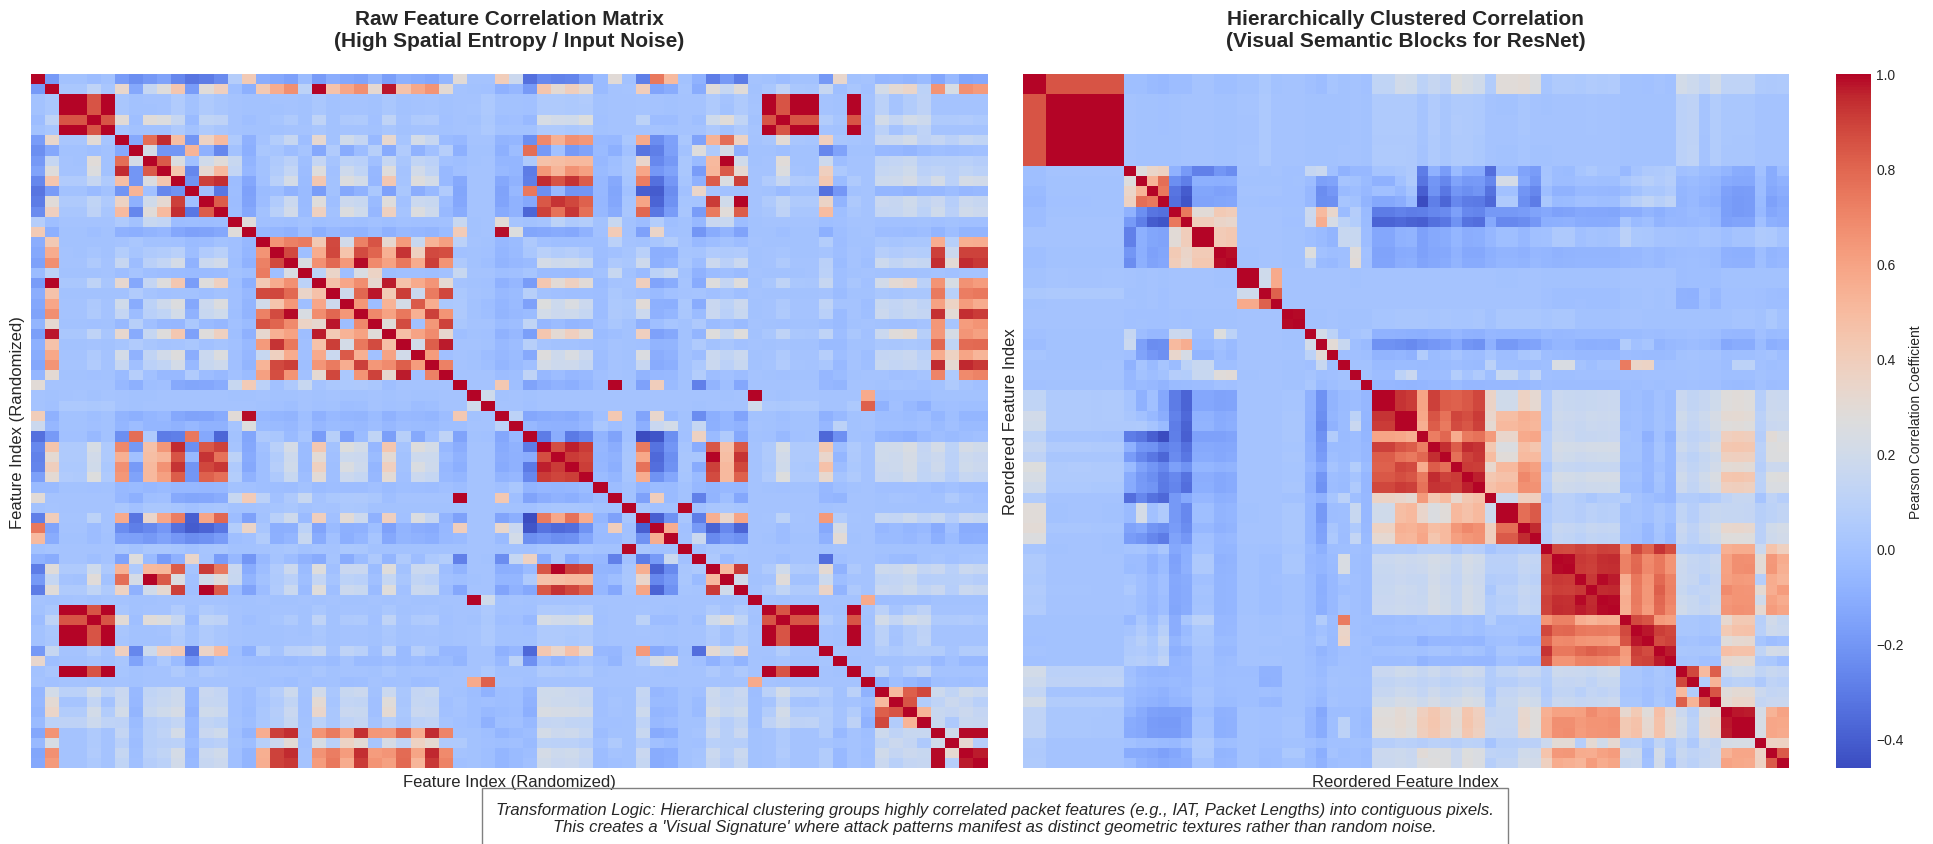

 Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


36771

In [ ]:
print(" Generating Monday Baseline file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 402,386 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (402,386 samples) for 10 Epochs...


Epoch 1/10: 100%|██████████| 3144/3144 [08:28<00:00,  6.19it/s, loss=0.0000]



📊 [Epoch 1] Train Loss: 0.0000 | Val Acc: 1.0000 | Macro F1: 1.0000
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 3144/3144 [08:26<00:00,  6.20it/s, loss=0.0000]



📊 [Epoch 2] Train Loss: 0.0000 | Val Acc: 1.0000 | Macro F1: 1.0000


...


📊 [Epoch 8] Train Loss: 0.0000 | Val Acc: 1.0000 | Macro F1: 1.0000


Epoch 9/10: 100%|██████████| 3144/3144 [08:26<00:00,  6.21it/s, loss=0.0000]



📊 [Epoch 9] Train Loss: 0.0000 | Val Acc: 1.0000 | Macro F1: 1.0000


Epoch 10/10: 100%|██████████| 3144/3144 [08:24<00:00,  6.23it/s, loss=0.0000]



📊 [Epoch 10] Train Loss: 0.0000 | Val Acc: 1.0000 | Macro F1: 1.0000

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 786/786 [02:14<00:00,  5.84it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  100.0000%
MACRO PRECISION:   1.0000
MACRO RECALL:      1.0000
MACRO F1-SCORE:    1.0000


,precision,recall,f1-score
BENIGN,1.0000,1.0000,1.0000


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


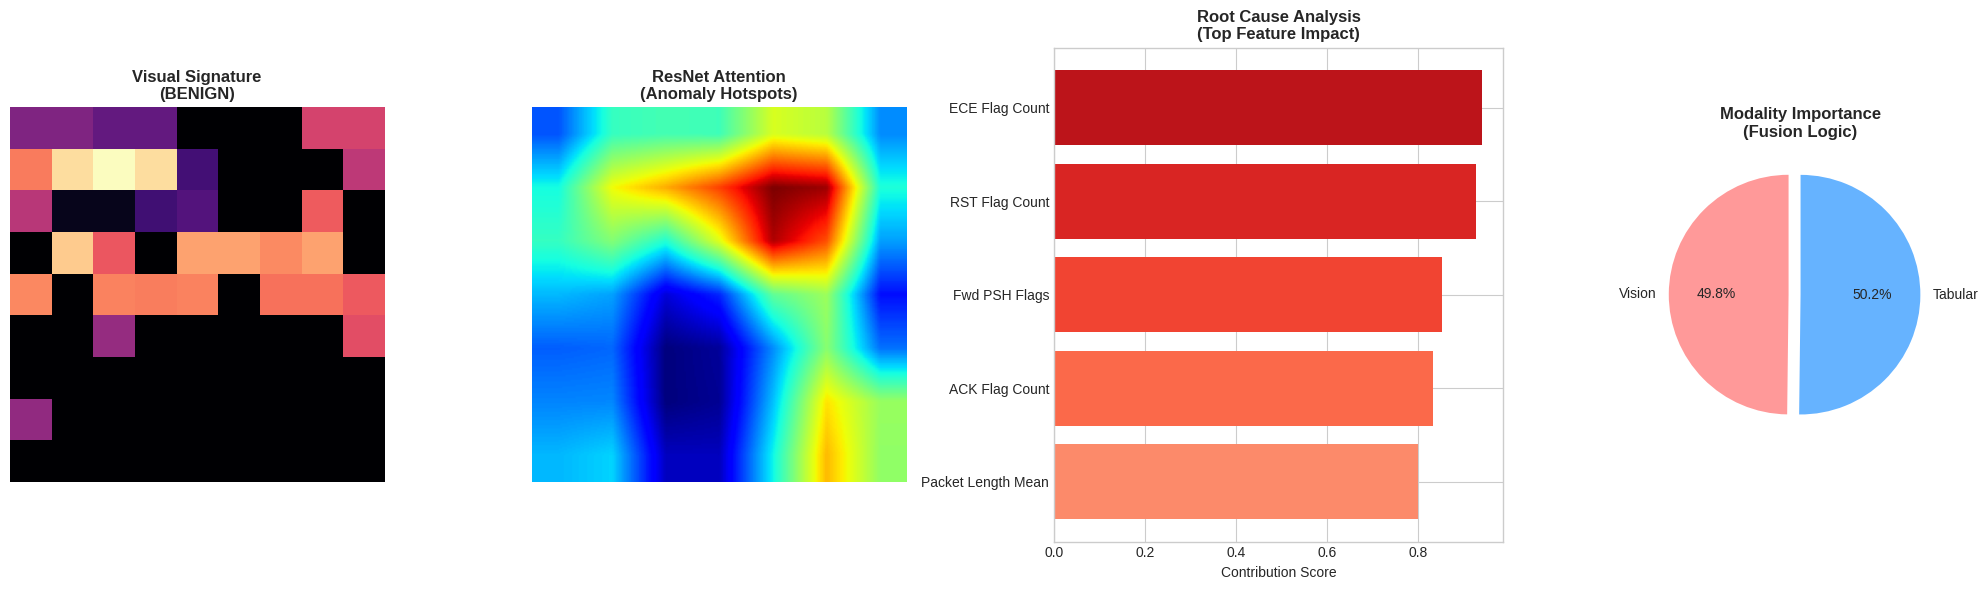

In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")

 ----------5. Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Raw Flow Shape: 288,602 Rows | 79 Columns
Post-Sanitization Volume: 252,972 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'Infiltration']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 8 zero-variance columns.
Modeling 70 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

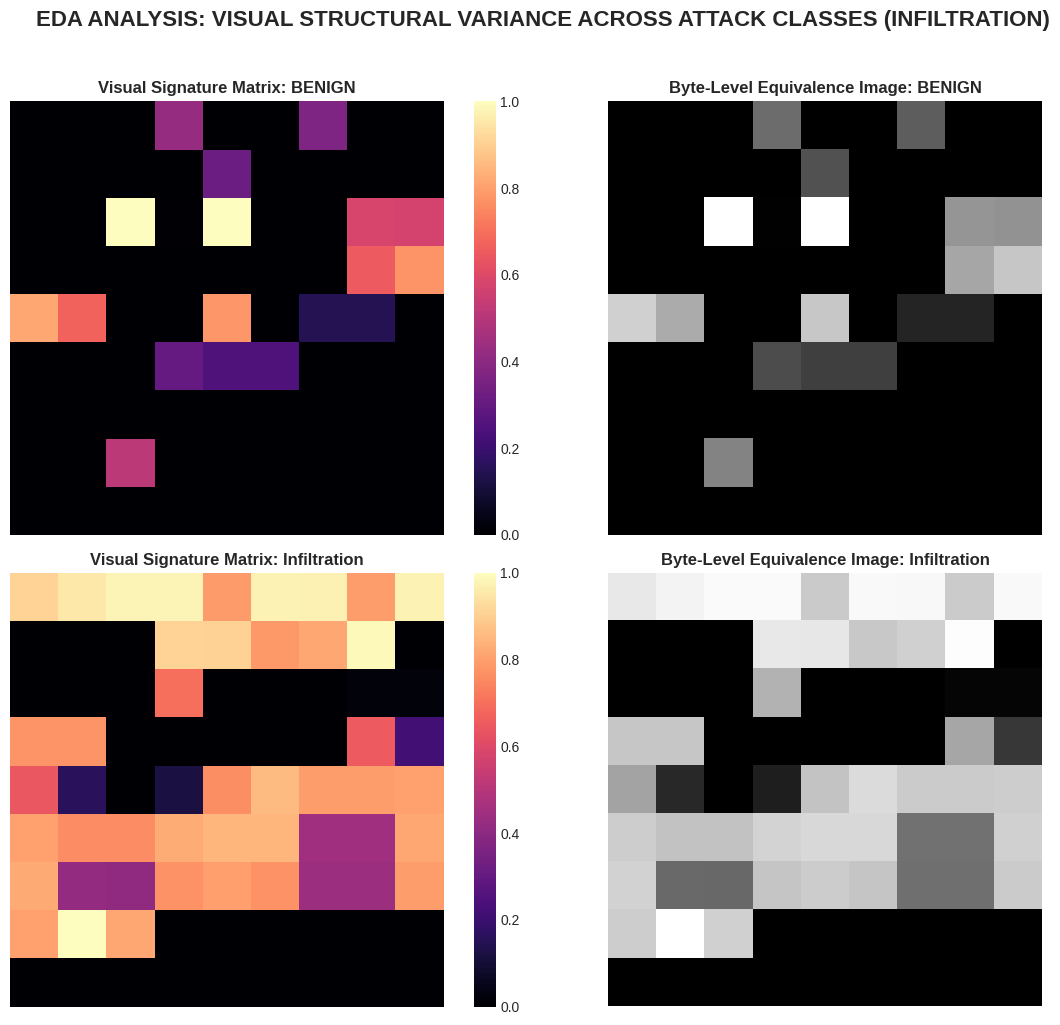

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (INFILTRATION)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

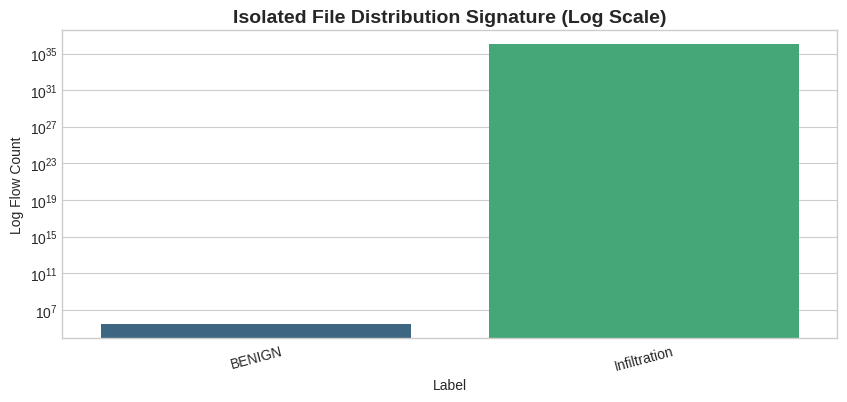

 Current Sub-split Frequency Index:
 🔹 BENIGN          : 252,936 flows (99.99%)
 🔹 Infiltration    : 36 flows (0.01%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Infiltration file correlation matrix transformation graphics...


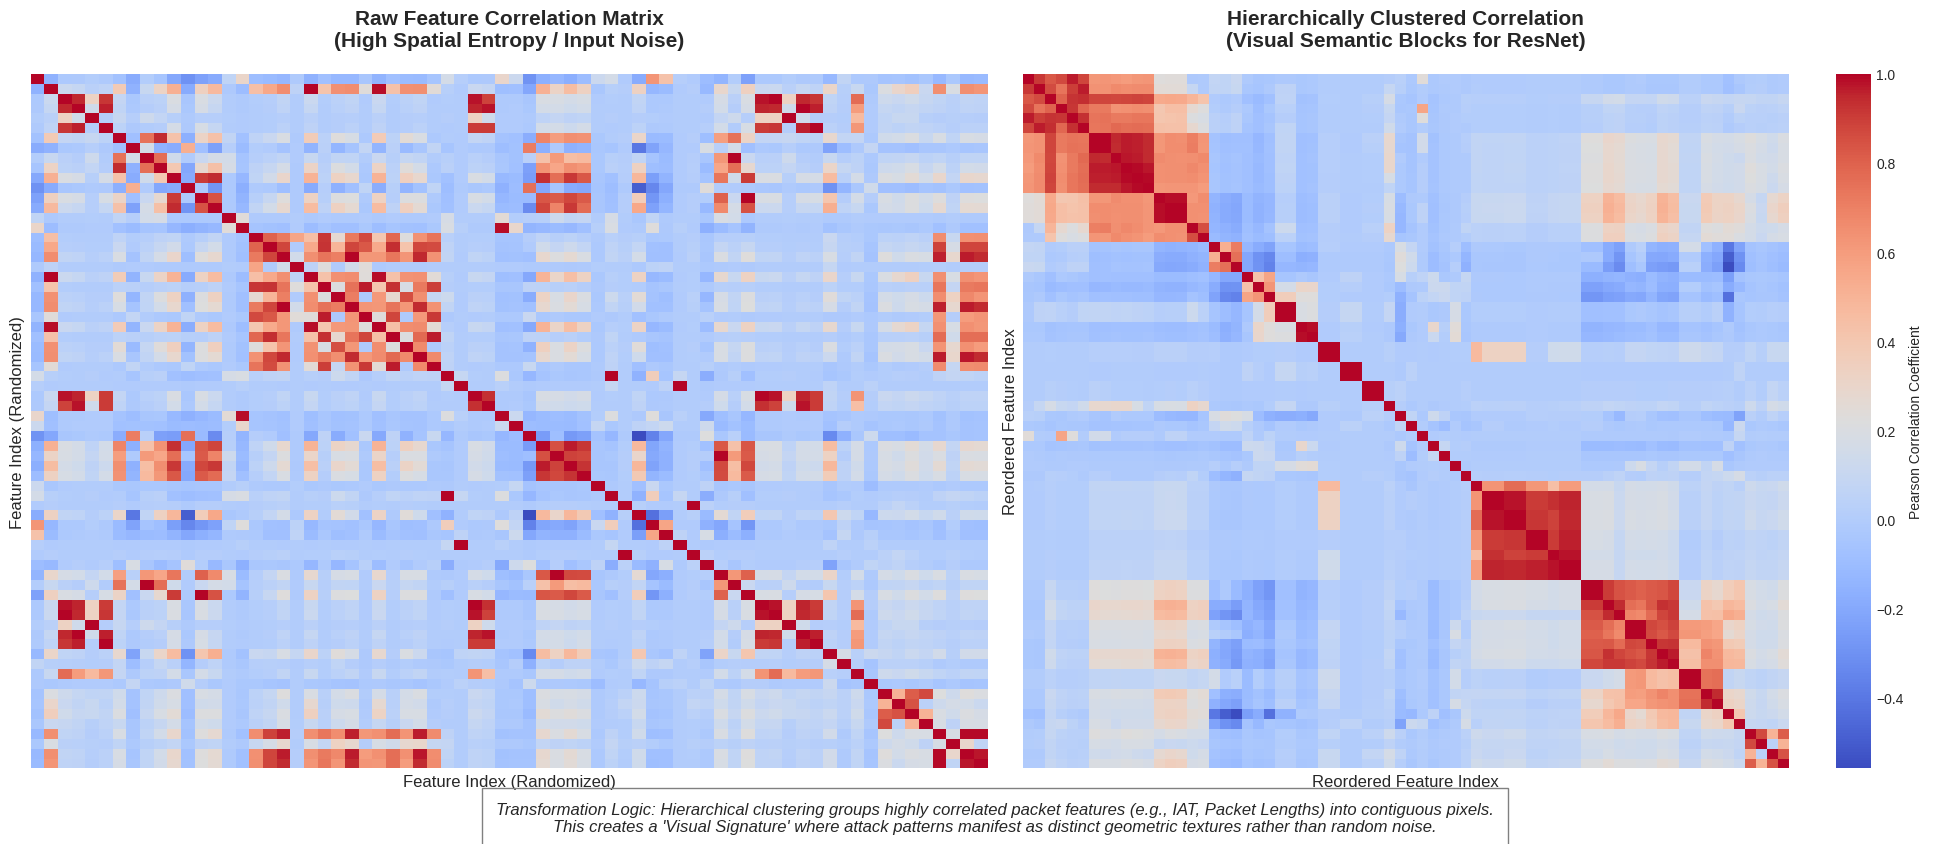

 Visualization complete. Reordering has successfully concentrated 70 features into dense visual structures.


1740

In [ ]:
print(" Generating Infiltration file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 202,377 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 230MB/s]


✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (202,377 samples) for 10 Epochs...


Epoch 1/10:   0%|          | 0/1582 [00:00<?, ?it/s]/tmp/ipykernel_522/3913796993.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/10: 100%|██████████| 1582/1582 [04:05<00:00,  6.44it/s, loss=0.0005]



📊 [Epoch 1] Train Loss: 0.0631 | Val Acc: 0.9999 | Macro F1: 0.8333
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 1582/1582 [04:13<00:00,  6.25it/s, loss=0.0001]



📊 [Epoch 2] Train Loss: 0.0095 | Val Acc: 0.9989 | Macro F1: 0.5732


...


📊 [Epoch 8] Train Loss: 0.0001 | Val Acc: 0.9999 | Macro F1: 0.8846


Epoch 9/10: 100%|██████████| 1582/1582 [05:19<00:00,  4.96it/s, loss=0.0008]



📊 [Epoch 9] Train Loss: 0.0000 | Val Acc: 0.9999 | Macro F1: 0.8846


Epoch 10/10: 100%|██████████| 1582/1582 [04:57<00:00,  5.31it/s, loss=0.0000]



📊 [Epoch 10] Train Loss: 0.0000 | Val Acc: 0.9999 | Macro F1: 0.8846

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 396/396 [01:12<00:00,  5.47it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.9960%
MACRO PRECISION:   1.0000
MACRO RECALL:      0.8571
MACRO F1-SCORE:    0.9167


,precision,recall,f1-score
BENIGN,1.0000,1.0000,1.0000
Infiltration,1.0000,0.7143,0.8333


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


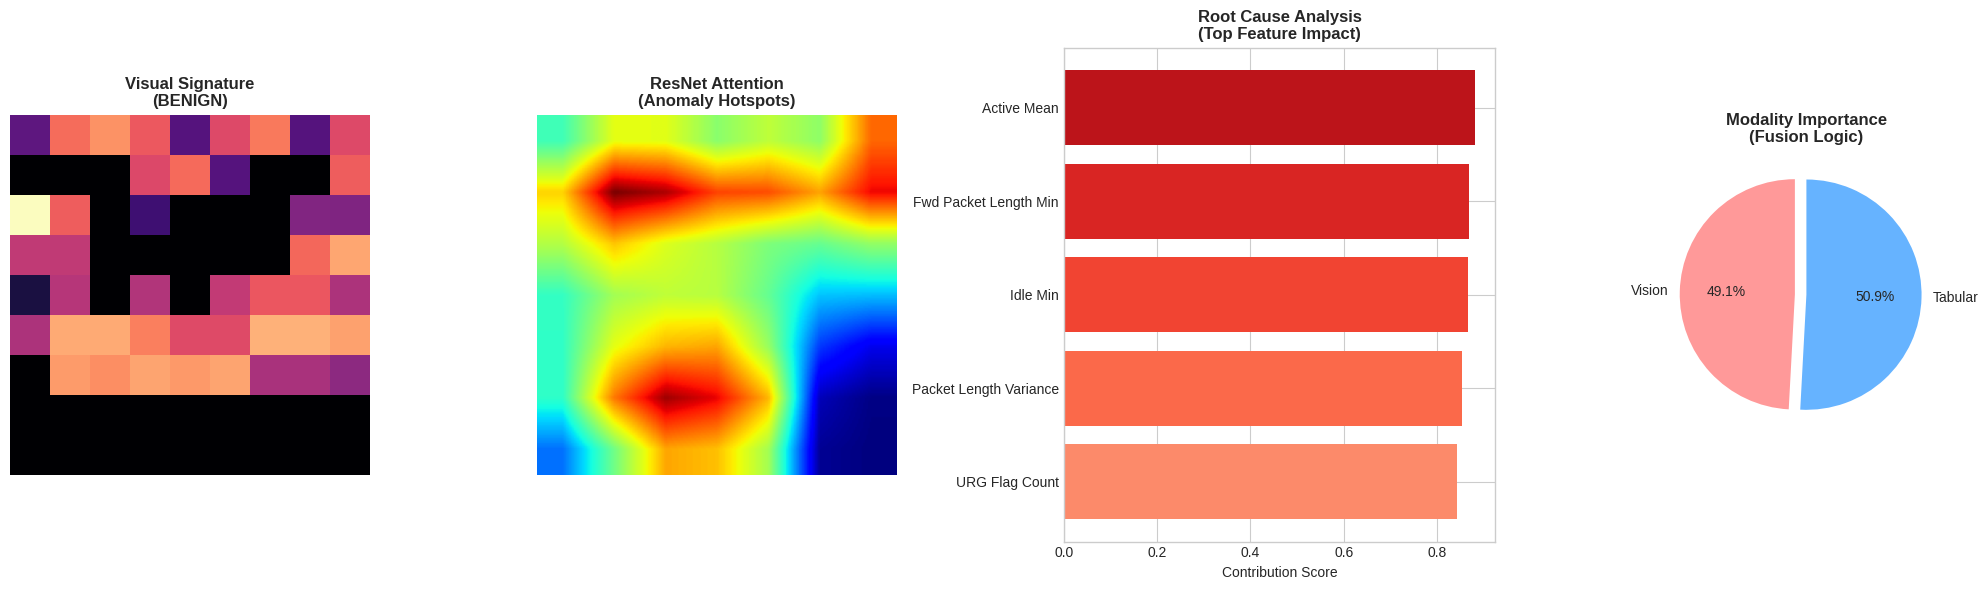

⚠️ No correct prediction found for Infiltration in current test sample.


In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")

----------6. Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization & Whitespace Sanitization
df['Label'] = df['Label'].str.strip()
# Resolve raw dataset naming typos structurally
df['Label'] = df['Label'].replace({
    'Web Attack  Brute Force': 'Web Attack - Brute Force',
    'Web Attack  XSS': 'Web Attack - XSS',
    'Web Attack  Sql Injection': 'Web Attack - Sql Injection'
})

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Raw Flow Shape: 170,366 Rows | 79 Columns
Post-Sanitization Volume: 164,300 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/tmp/ipykernel_522/3826502724.py:26: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


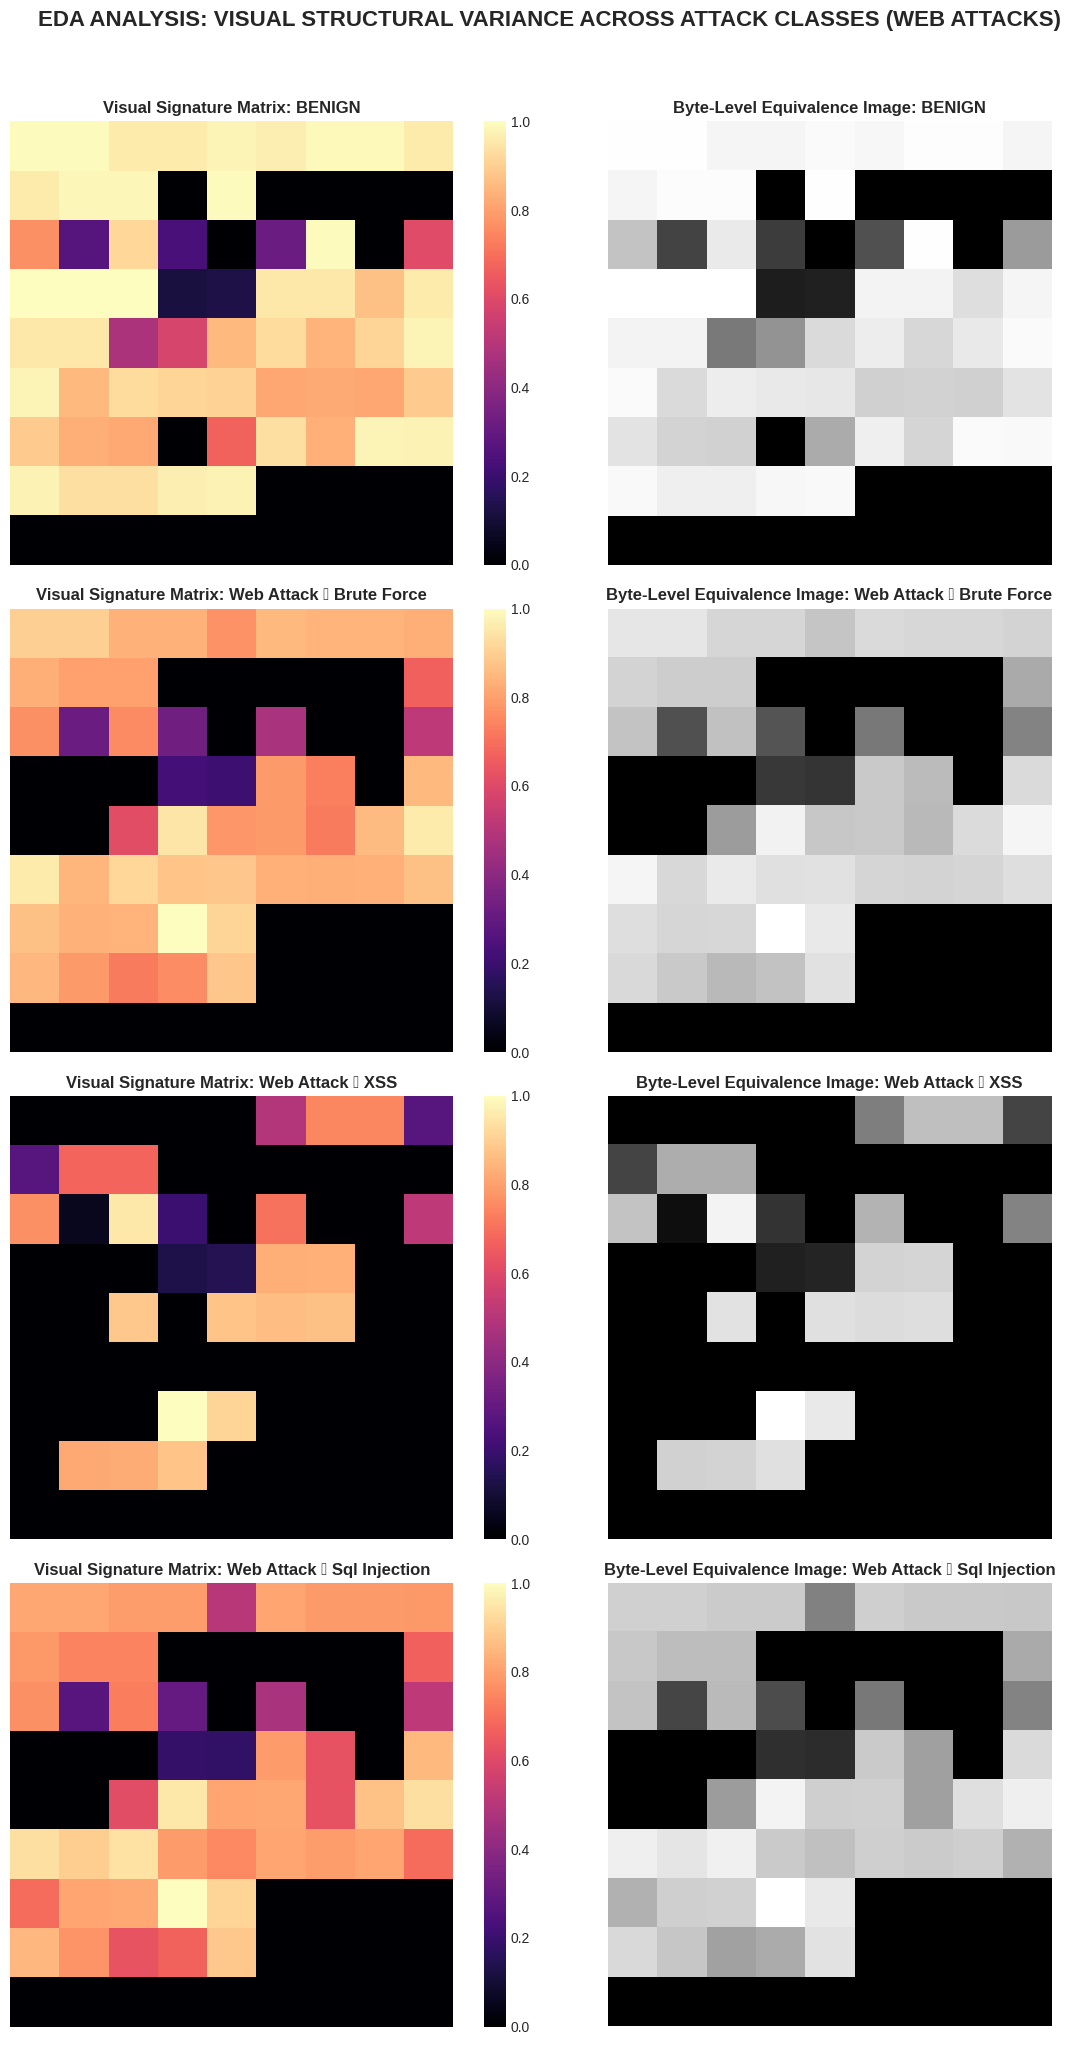

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (WEB ATTACKS)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


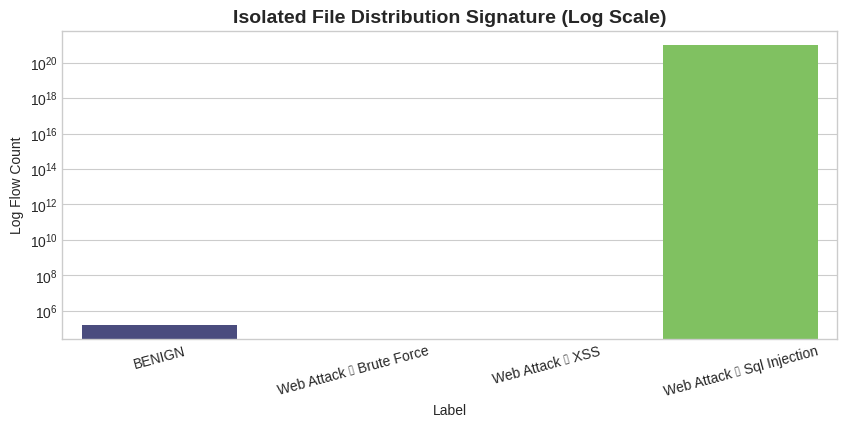

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 162,157 flows (98.70%)
 🔹 Web Attack � Brute Force : 1,470 flows (0.89%)
 🔹 Web Attack � XSS : 652 flows (0.40%)
 🔹 Web Attack � Sql Injection : 21 flows (0.01%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("📝 Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

📊 Generating Web Attacks file correlation matrix transformation graphics...


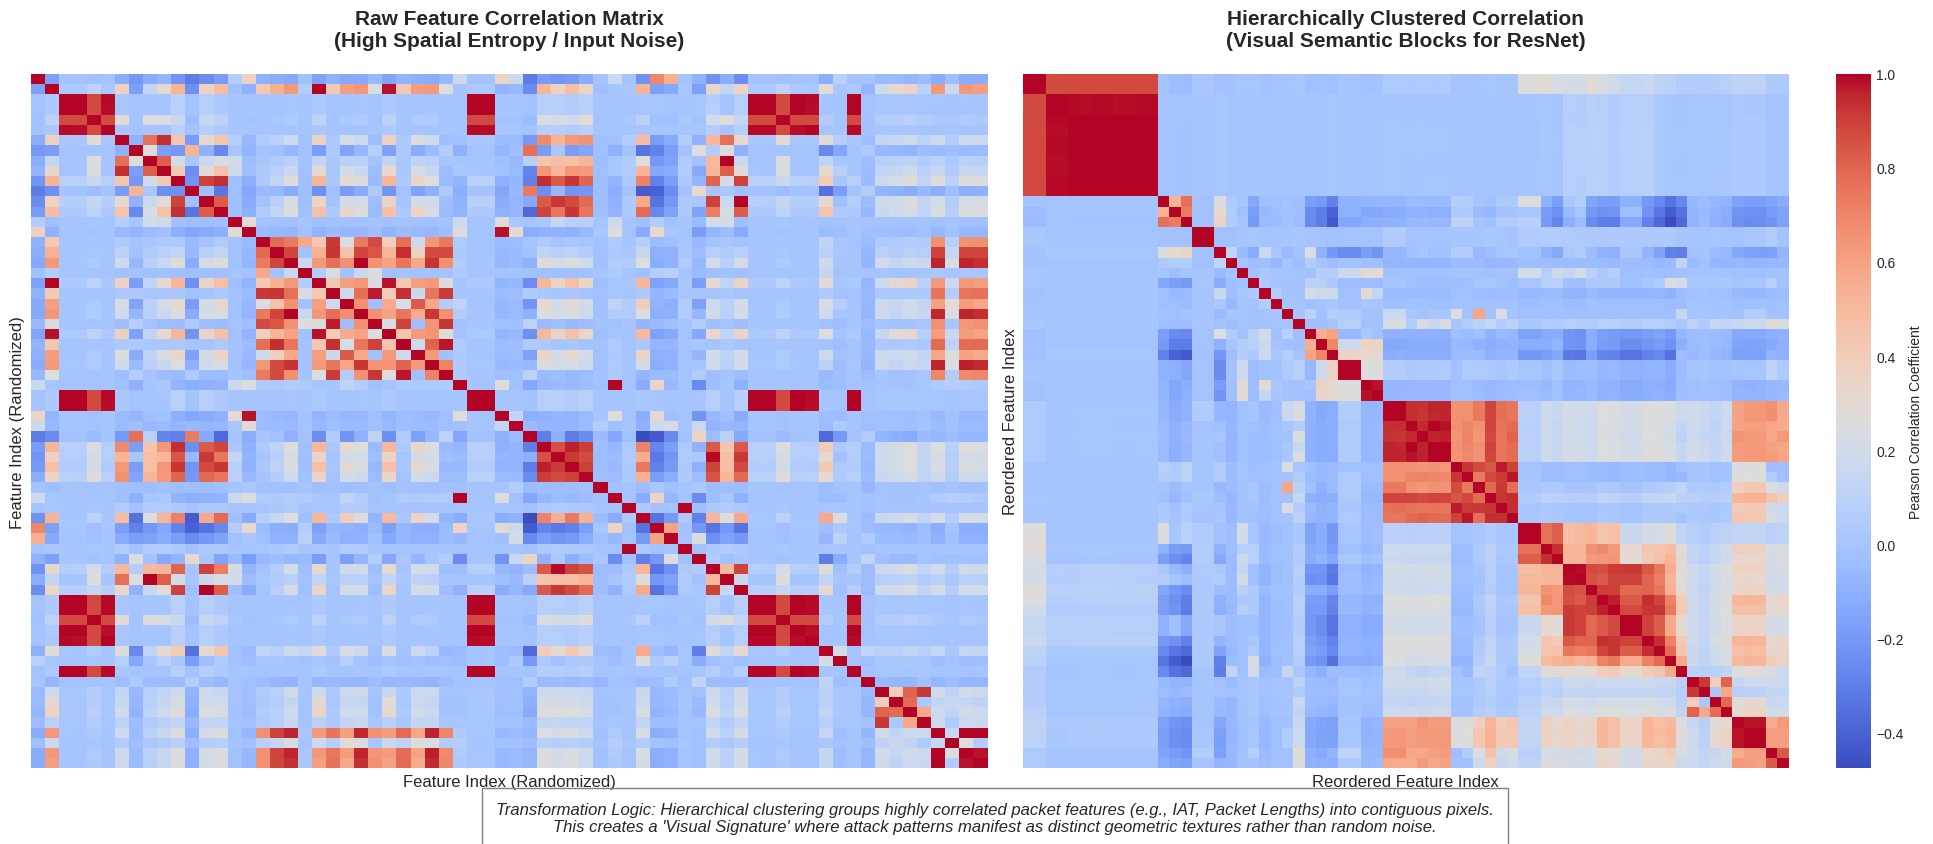

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


34402

In [ ]:
print("📊 Generating Web Attacks file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"✅ Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 131,440 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (131,440 samples) for 10 Epochs...


Epoch 1/10:   0%|          | 0/1027 [00:00<?, ?it/s]/tmp/ipykernel_522/3913796993.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/10: 100%|██████████| 1027/1027 [02:47<00:00,  6.14it/s, loss=0.6549]



📊 [Epoch 1] Train Loss: 1.6749 | Val Acc: 0.9818 | Macro F1: 0.4778
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 1027/1027 [02:43<00:00,  6.30it/s, loss=0.8156]



📊 [Epoch 2] Train Loss: 1.2609 | Val Acc: 0.9896 | Macro F1: 0.4757


...


📊 [Epoch 8] Train Loss: 1.0453 | Val Acc: 0.9948 | Macro F1: 0.6368


Epoch 9/10: 100%|██████████| 1027/1027 [02:42<00:00,  6.31it/s, loss=0.5702]



📊 [Epoch 9] Train Loss: 0.9955 | Val Acc: 0.9950 | Macro F1: 0.6608


Epoch 10/10: 100%|██████████| 1027/1027 [02:41<00:00,  6.36it/s, loss=1.4194]



📊 [Epoch 10] Train Loss: 1.0034 | Val Acc: 0.9950 | Macro F1: 0.6808
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 257/257 [00:42<00:00,  6.04it/s]


🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.4979%
MACRO PRECISION:   0.6916
MACRO RECALL:      0.7051
MACRO F1-SCORE:    0.6808


,precision,recall,f1-score
BENIGN,1.0000,0.9999,1.0000
Web Attack � Brute Force,0.8342,0.5646,0.6734
Web Attack � Sql Injection,0.5000,0.5000,0.5000
Web Attack � XSS,0.4323,0.7557,0.5500


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: -B-E-N-I-G-N-
############################################################


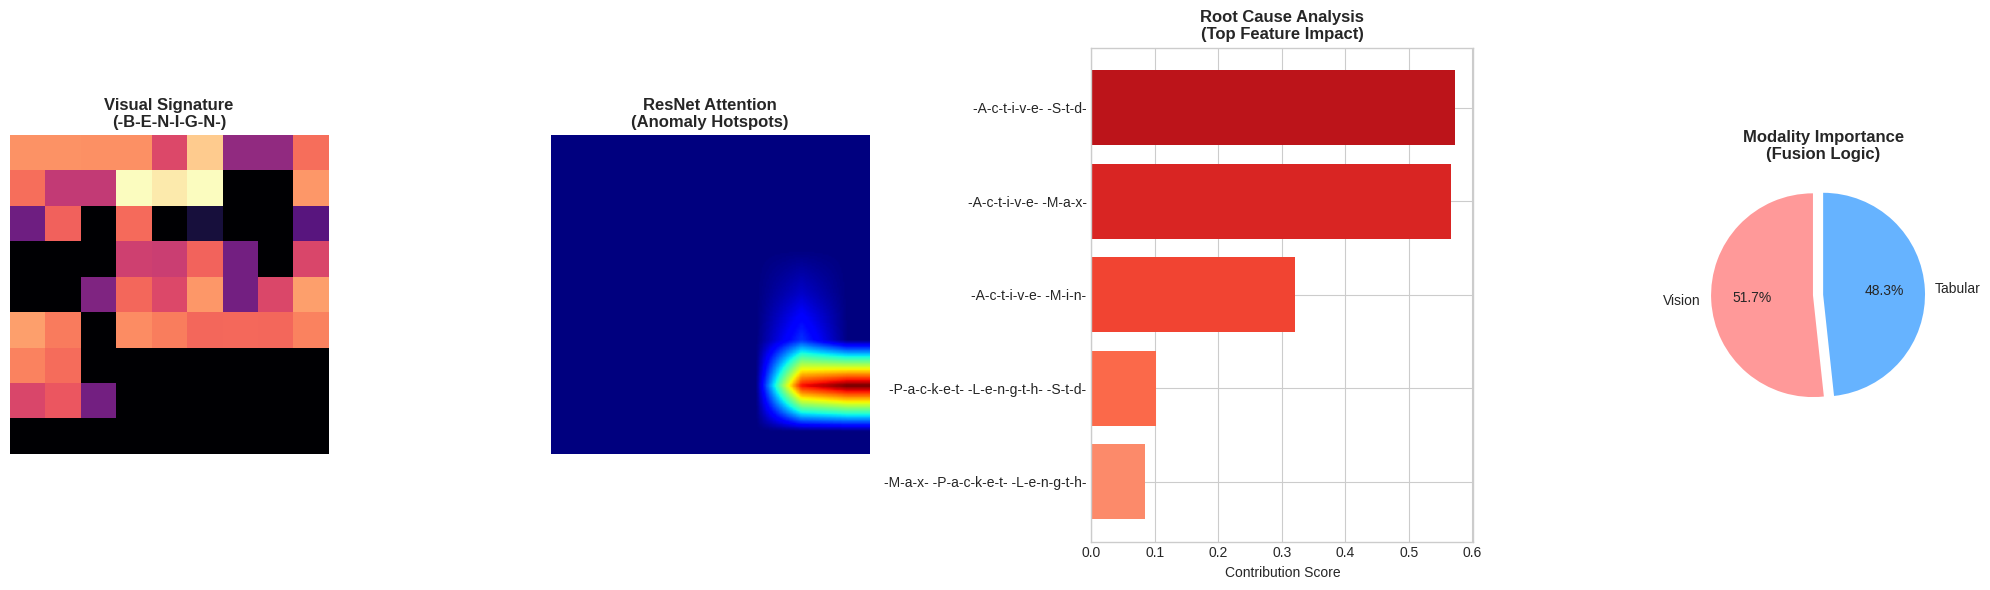

⚠️ No correct prediction found for -W-e-b- -A-t-t-a-c-k- -�- -B-r-u-t-e- -F-o-r-c-e- in current test sample.
⚠️ No correct prediction found for -W-e-b- -A-t-t-a-c-k- -�- -S-q-l- -I-n-j-e-c-t-i-o-n- in current test sample.

############################################################
# SOC ANALYST INTELLIGENCE: -W-E-B- -A-T-T-A-C-K- -�- -X-S-S-
############################################################


/tmp/ipykernel_522/3150569600.py:81: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


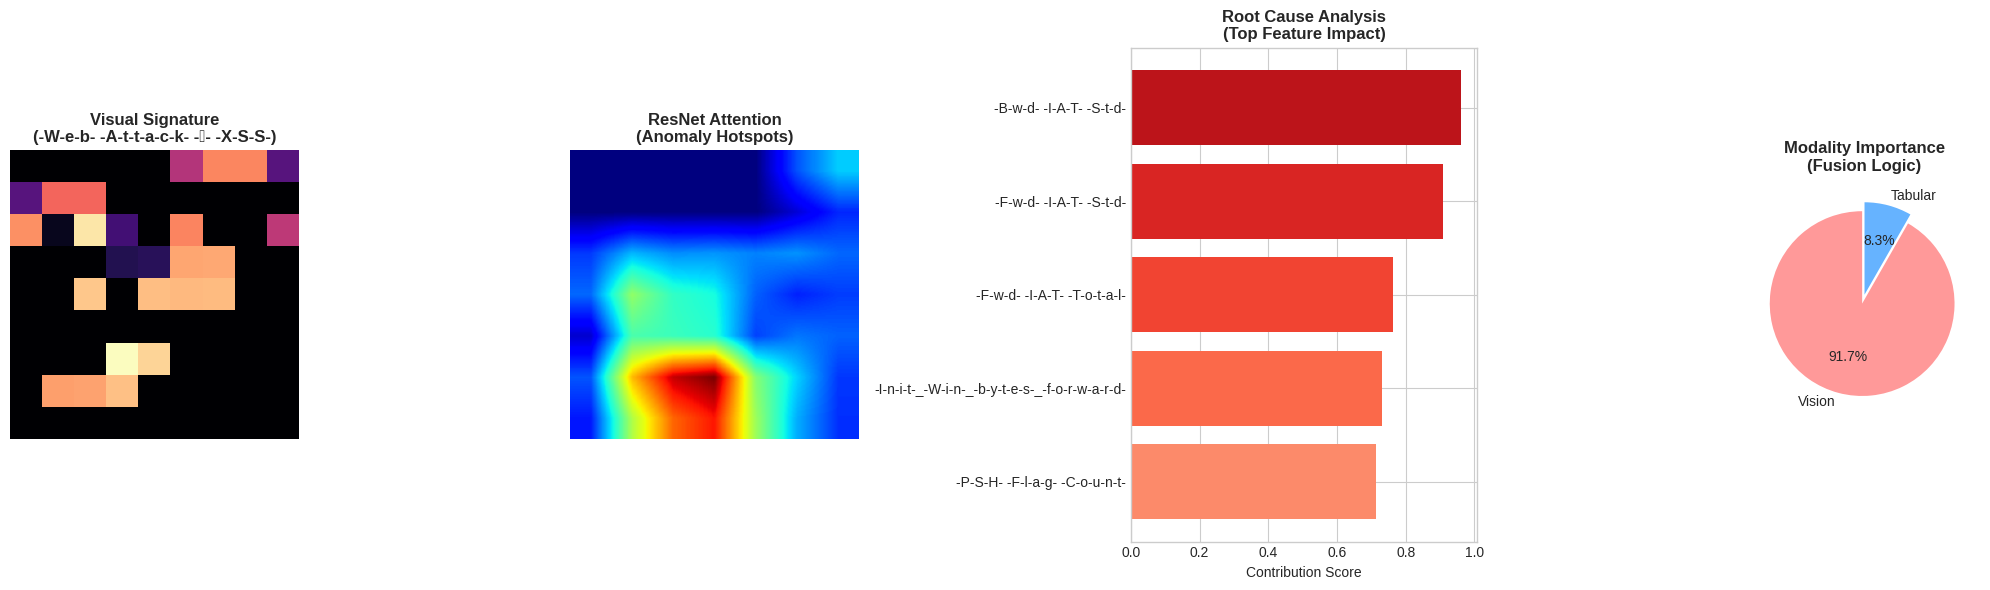

In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name.replace('', '-')})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]].replace('', '-') for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        # Clean the attack name before printing
        clean_attack_name = attack.replace('', '-')
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {clean_attack_name.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack.replace('', '-')} in current test sample.")

----------7. Tuesday-WorkingHours.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Tuesday-WorkingHours.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Tuesday-WorkingHours.pcap_ISCX.csv
Raw Flow Shape: 445,909 Rows | 79 Columns
Post-Sanitization Volume: 421,844 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'FTP-Patator' 'SSH-Patator']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

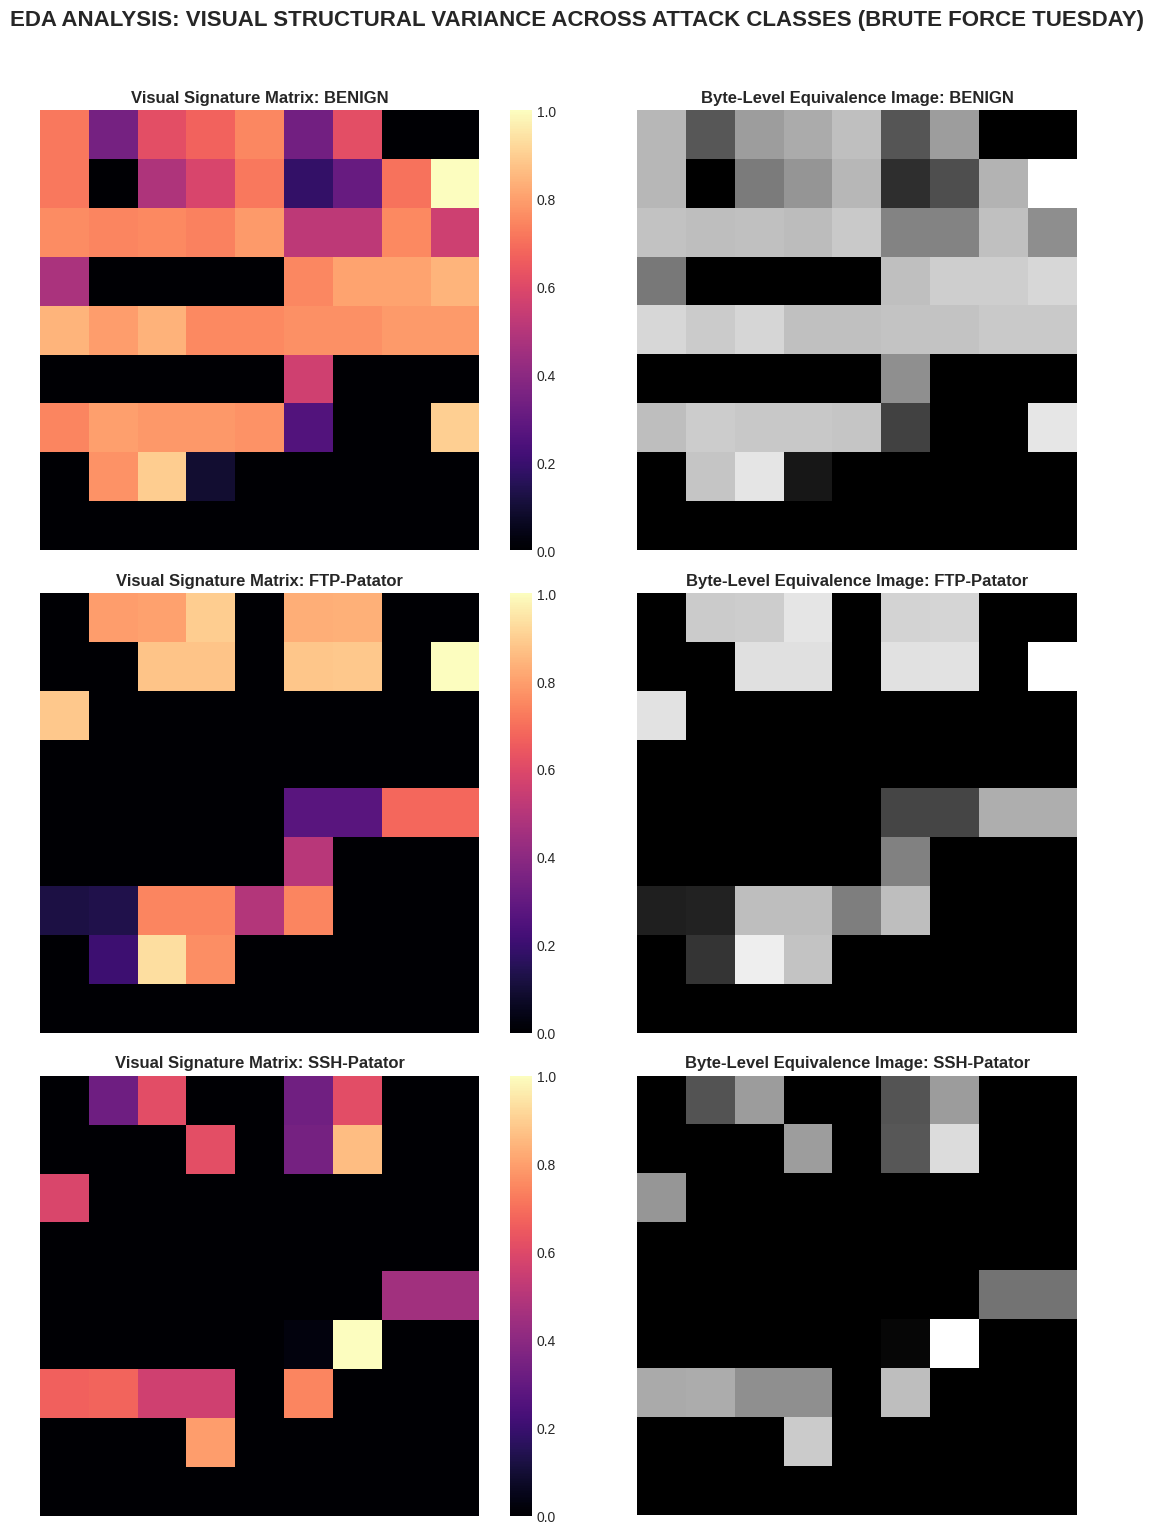

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (BRUTE FORCE TUESDAY)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


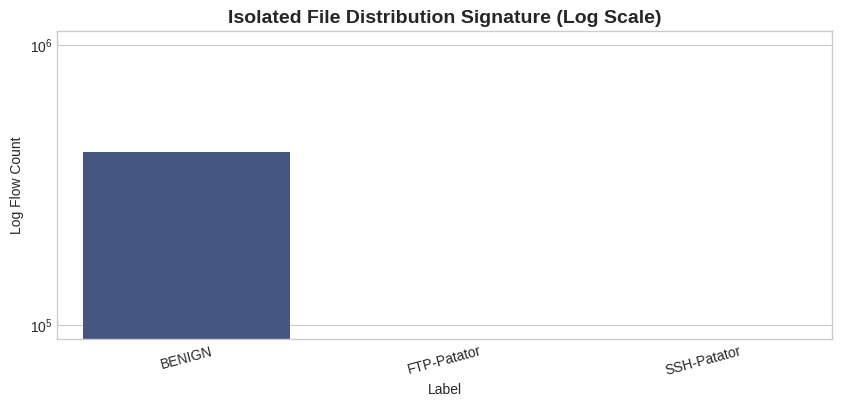

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 412,692 flows (97.83%)
 🔹 FTP-Patator     : 5,933 flows (1.41%)
 🔹 SSH-Patator     : 3,219 flows (0.76%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("📝 Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

📊 Generating Tuesday Brute Force file correlation matrix transformation graphics...


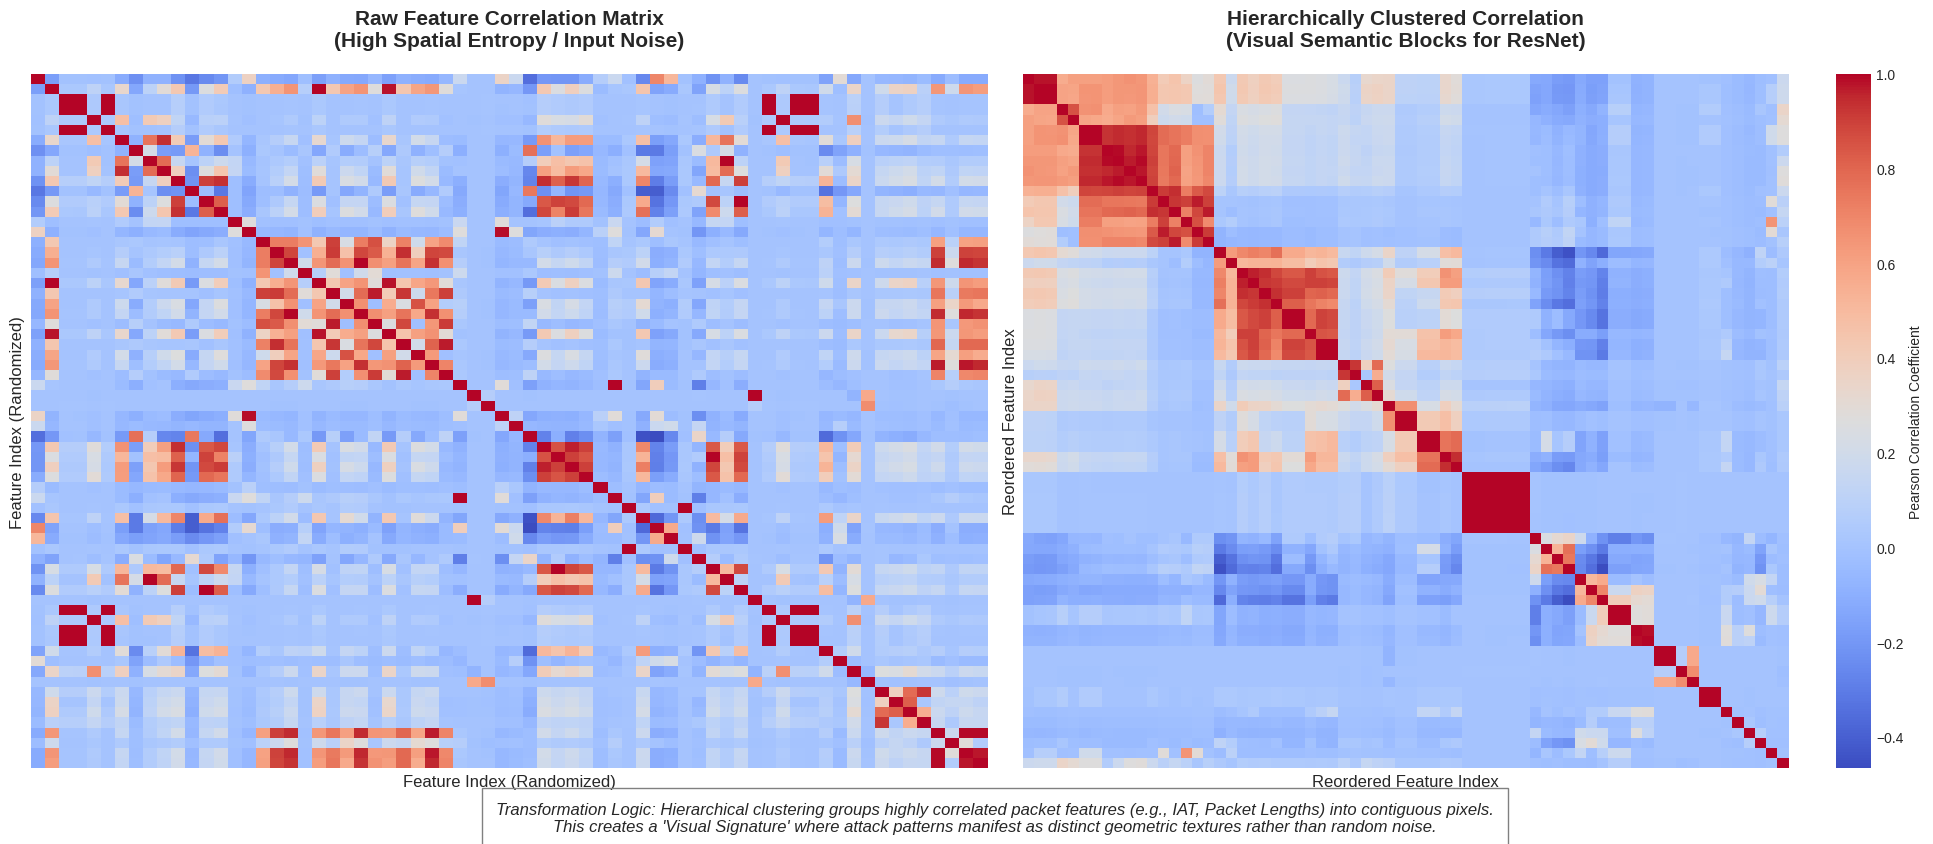

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


241

In [ ]:
print("📊 Generating Tuesday Brute Force file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"✅ Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 337,475 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (337,475 samples) for 10 Epochs...


Epoch 1/10: 100%|██████████| 2637/2637 [06:55<00:00,  6.34it/s, loss=0.0004]



📊 [Epoch 1] Train Loss: 0.0616 | Val Acc: 0.9995 | Macro F1: 0.9888
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 2637/2637 [07:58<00:00,  5.51it/s, loss=0.0000]



📊 [Epoch 2] Train Loss: 0.0107 | Val Acc: 0.9996 | Macro F1: 0.9913
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


...


📊 [Epoch 8] Train Loss: 0.0010 | Val Acc: 0.9999 | Macro F1: 0.9975
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 9/10: 100%|██████████| 2637/2637 [08:03<00:00,  5.46it/s, loss=0.0000]



📊 [Epoch 9] Train Loss: 0.0004 | Val Acc: 0.9999 | Macro F1: 0.9984
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 10/10: 100%|██████████| 2637/2637 [09:02<00:00,  4.86it/s, loss=0.0000]



📊 [Epoch 10] Train Loss: 0.0002 | Val Acc: 0.9999 | Macro F1: 0.9975

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 660/660 [02:24<00:00,  4.57it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.9905%
MACRO PRECISION:   0.9968
MACRO RECALL:      1.0000
MACRO F1-SCORE:    0.9984


,precision,recall,f1-score
BENIGN,1.0000,0.9999,1.0000
FTP-Patator,0.9966,1.0000,0.9983
SSH-Patator,0.9938,1.0000,0.9969


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


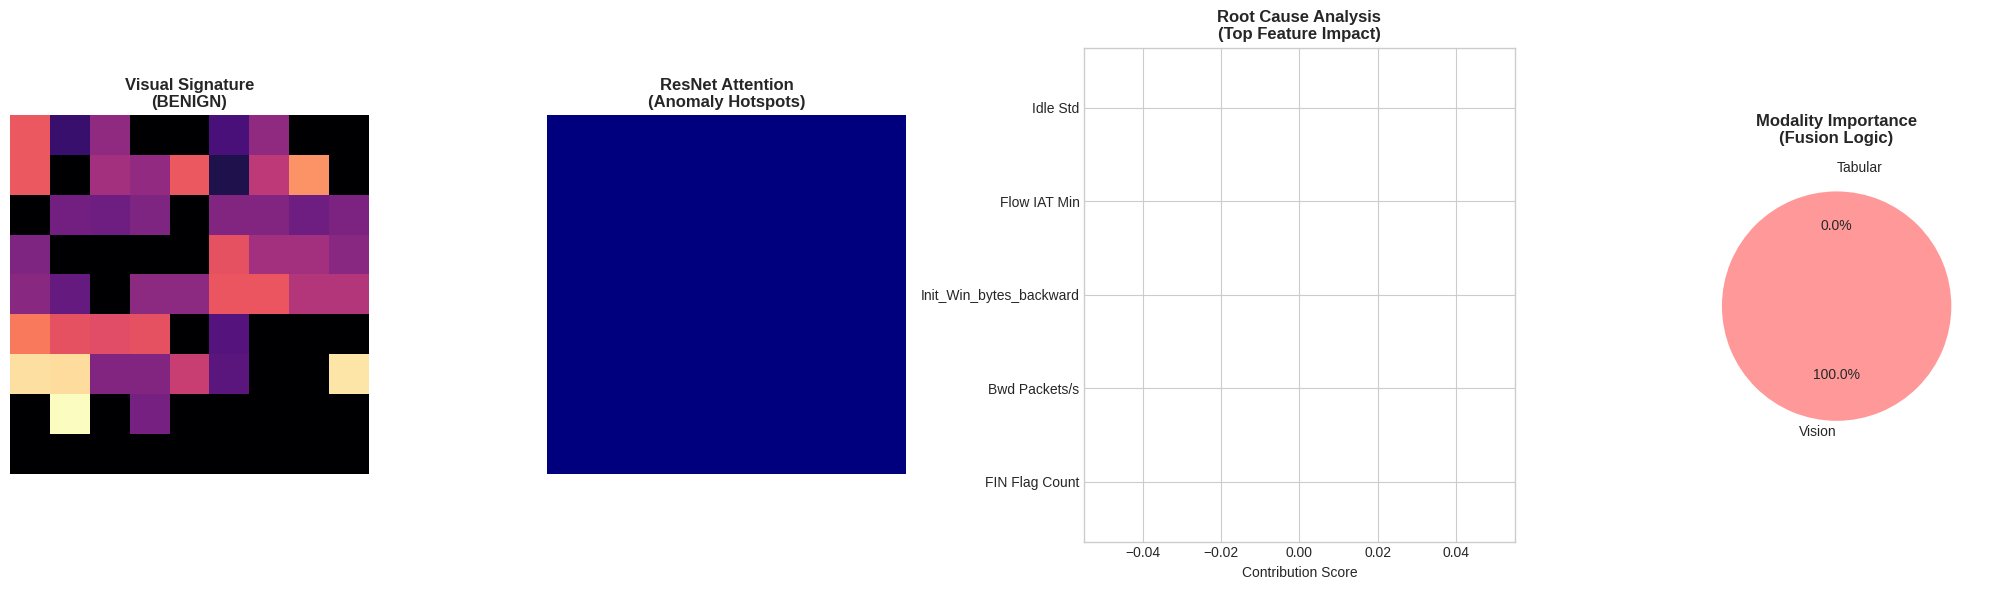


############################################################
# SOC ANALYST INTELLIGENCE: FTP-PATATOR
############################################################


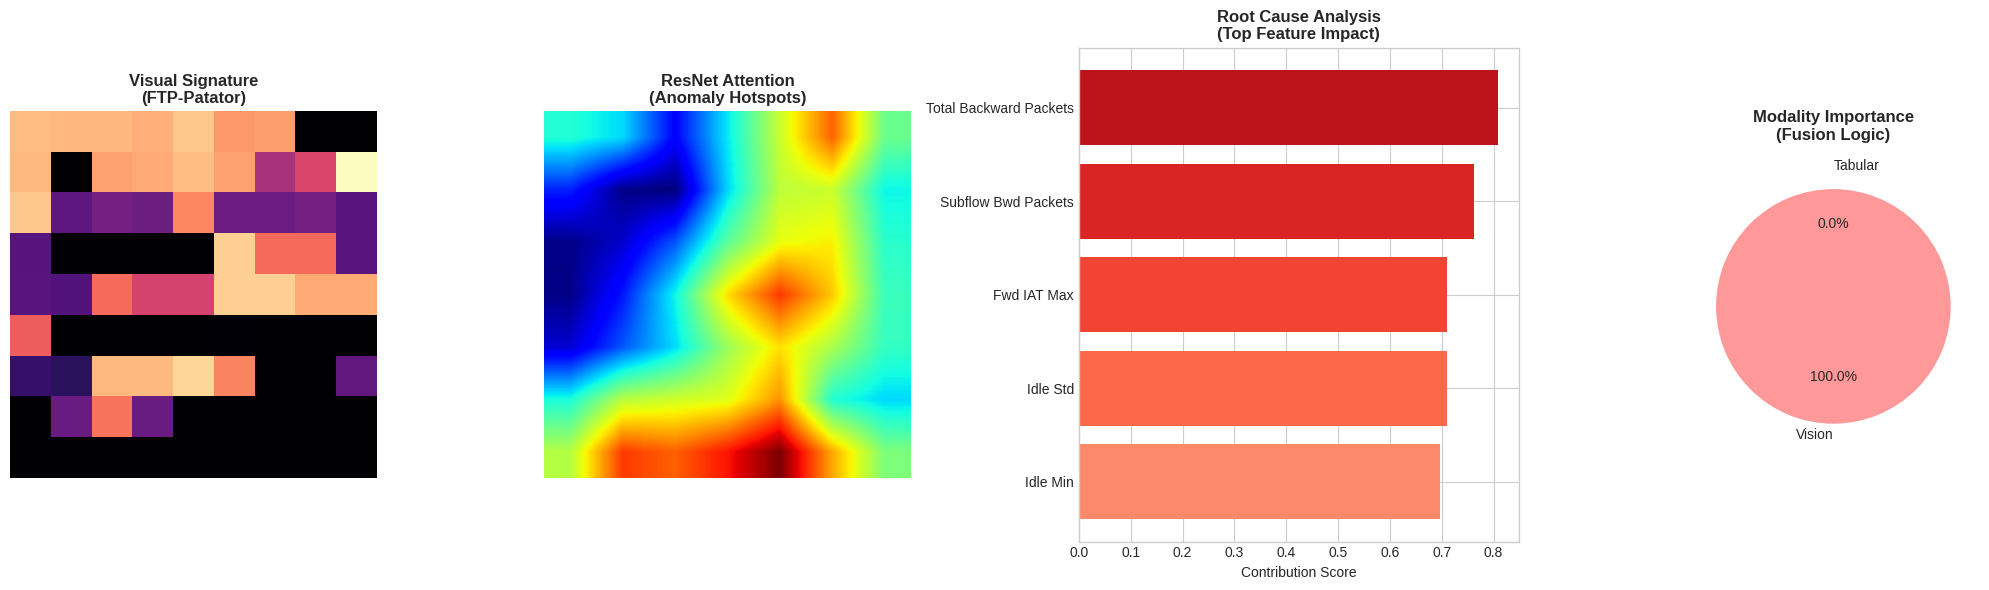

⚠️ No correct prediction found for SSH-Patator in current test sample.


In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")

 ----------8. Wednesday-workingHours.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Wednesday-workingHours.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip leading/trailing spaces in column headers

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization & Whitespace Sanitization
df['Label'] = df['Label'].str.strip()
# Standardize any internal typos matching raw dataset anomalies
df['Label'] = df['Label'].replace({
    'DoS Hulk': 'DoS Hulk',
    'DoS GoldenEye': 'DoS GoldenEye',
    'DoS slowloris': 'DoS slowloris',
    'DoS Slowhttptest': 'DoS Slowhttptest',
    'Heartbleed': 'Heartbleed'
})

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Wednesday-workingHours.pcap_ISCX.csv
Raw Flow Shape: 692,703 Rows | 79 Columns
Post-Sanitization Volume: 610,794 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [ ]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [ ]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

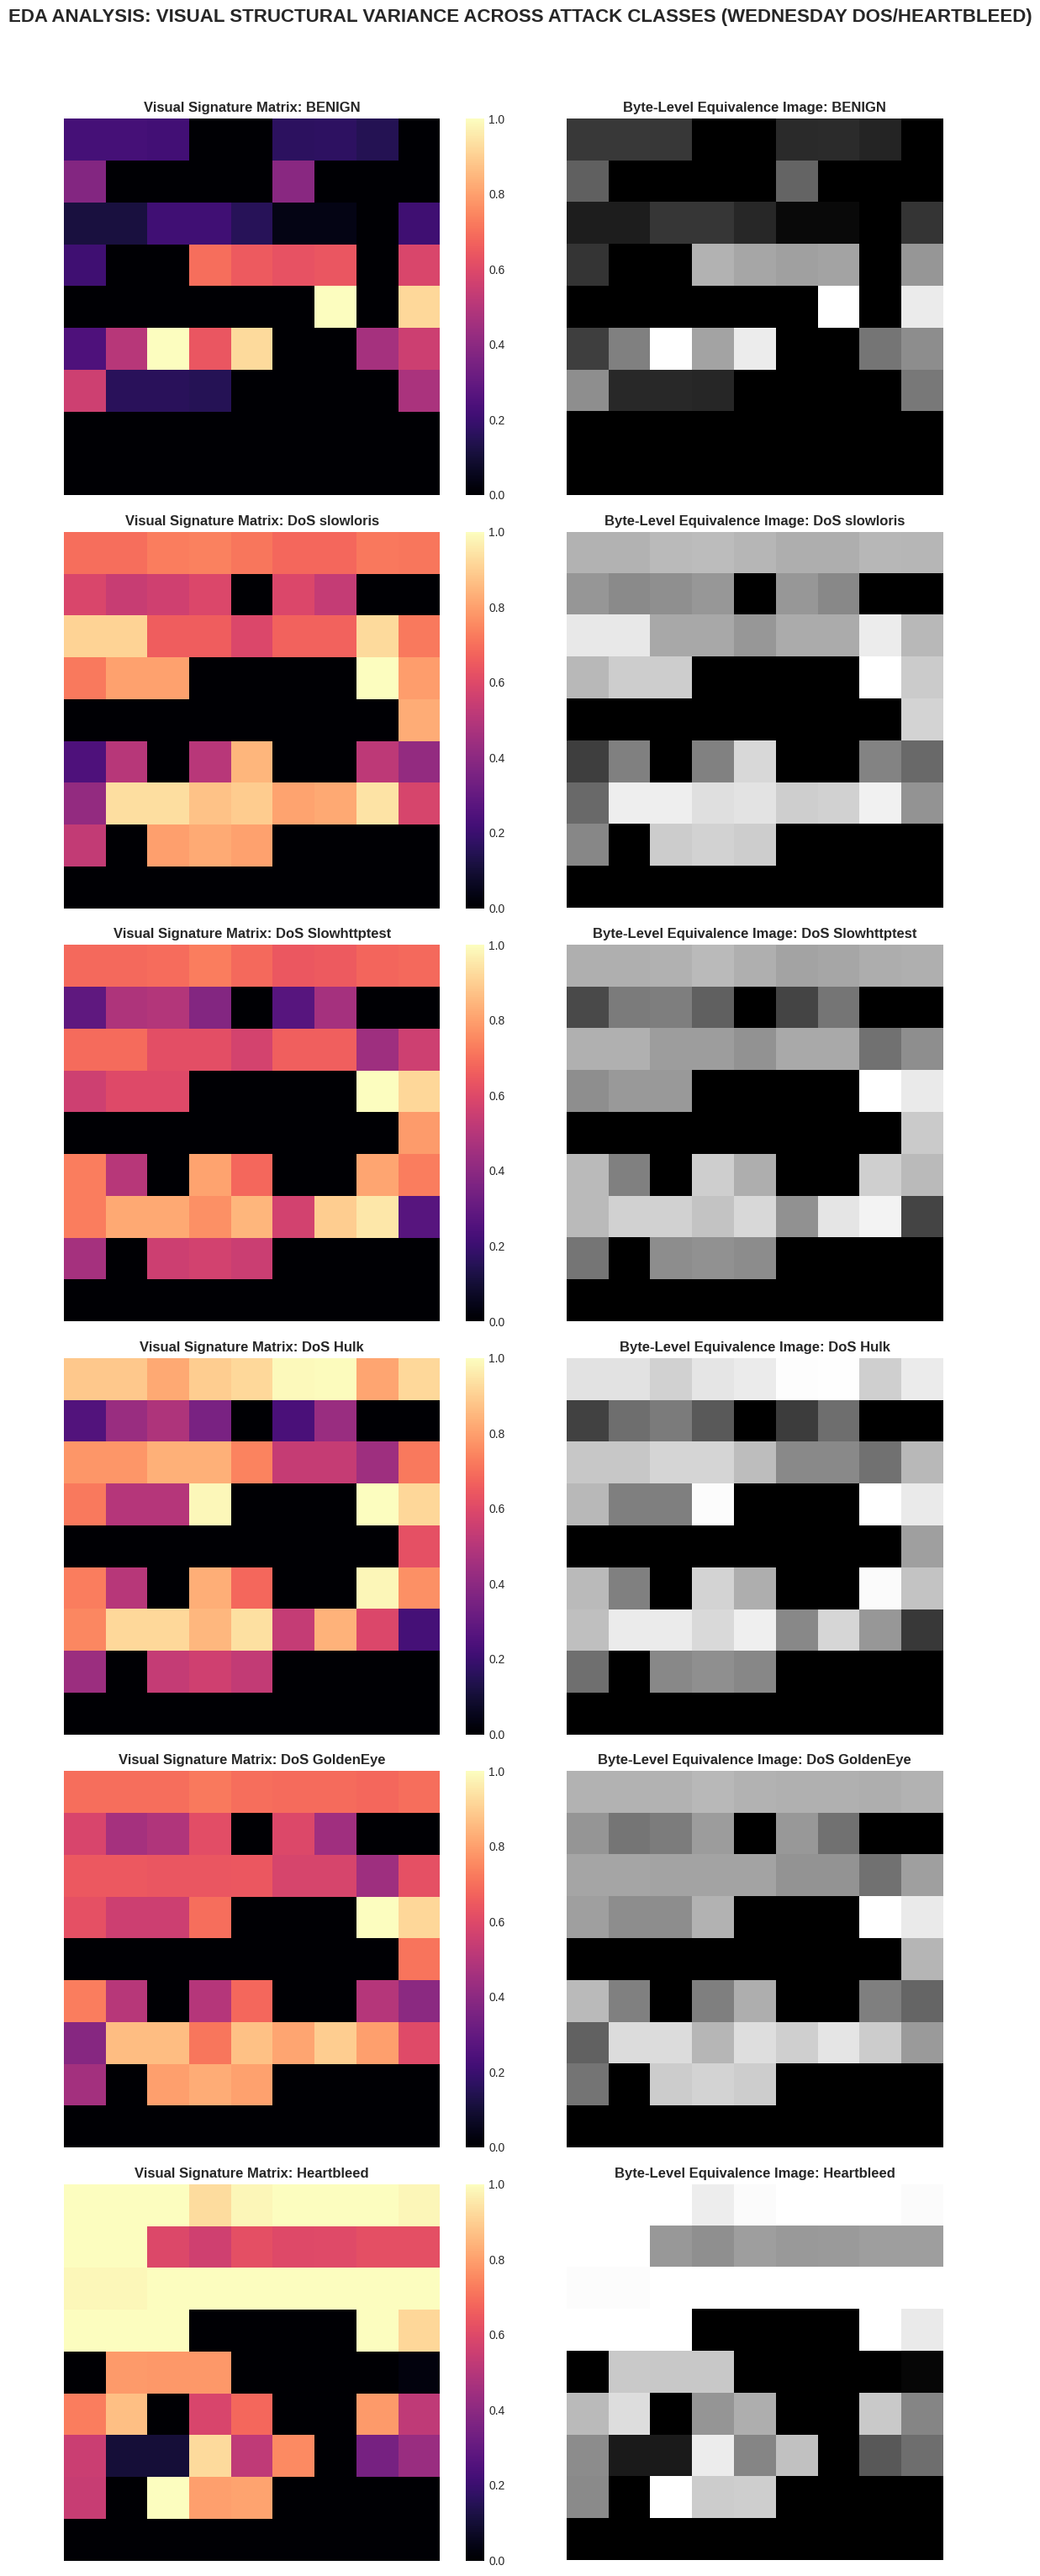

In [ ]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (WEDNESDAY DOS/HEARTBLEED)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


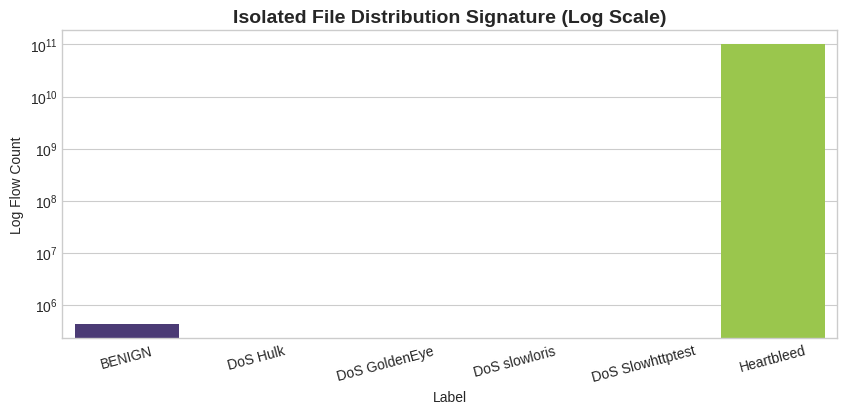

 Current Sub-split Frequency Index:
 🔹 BENIGN          : 417,035 flows (68.28%)
 🔹 DoS Hulk        : 172,849 flows (28.30%)
 🔹 DoS GoldenEye   : 10,286 flows (1.68%)
 🔹 DoS slowloris   : 5,385 flows (0.88%)
 🔹 DoS Slowhttptest : 5,228 flows (0.86%)
 🔹 Heartbleed      : 11 flows (0.00%)


In [ ]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Wednesday DoS file correlation matrix transformation graphics...


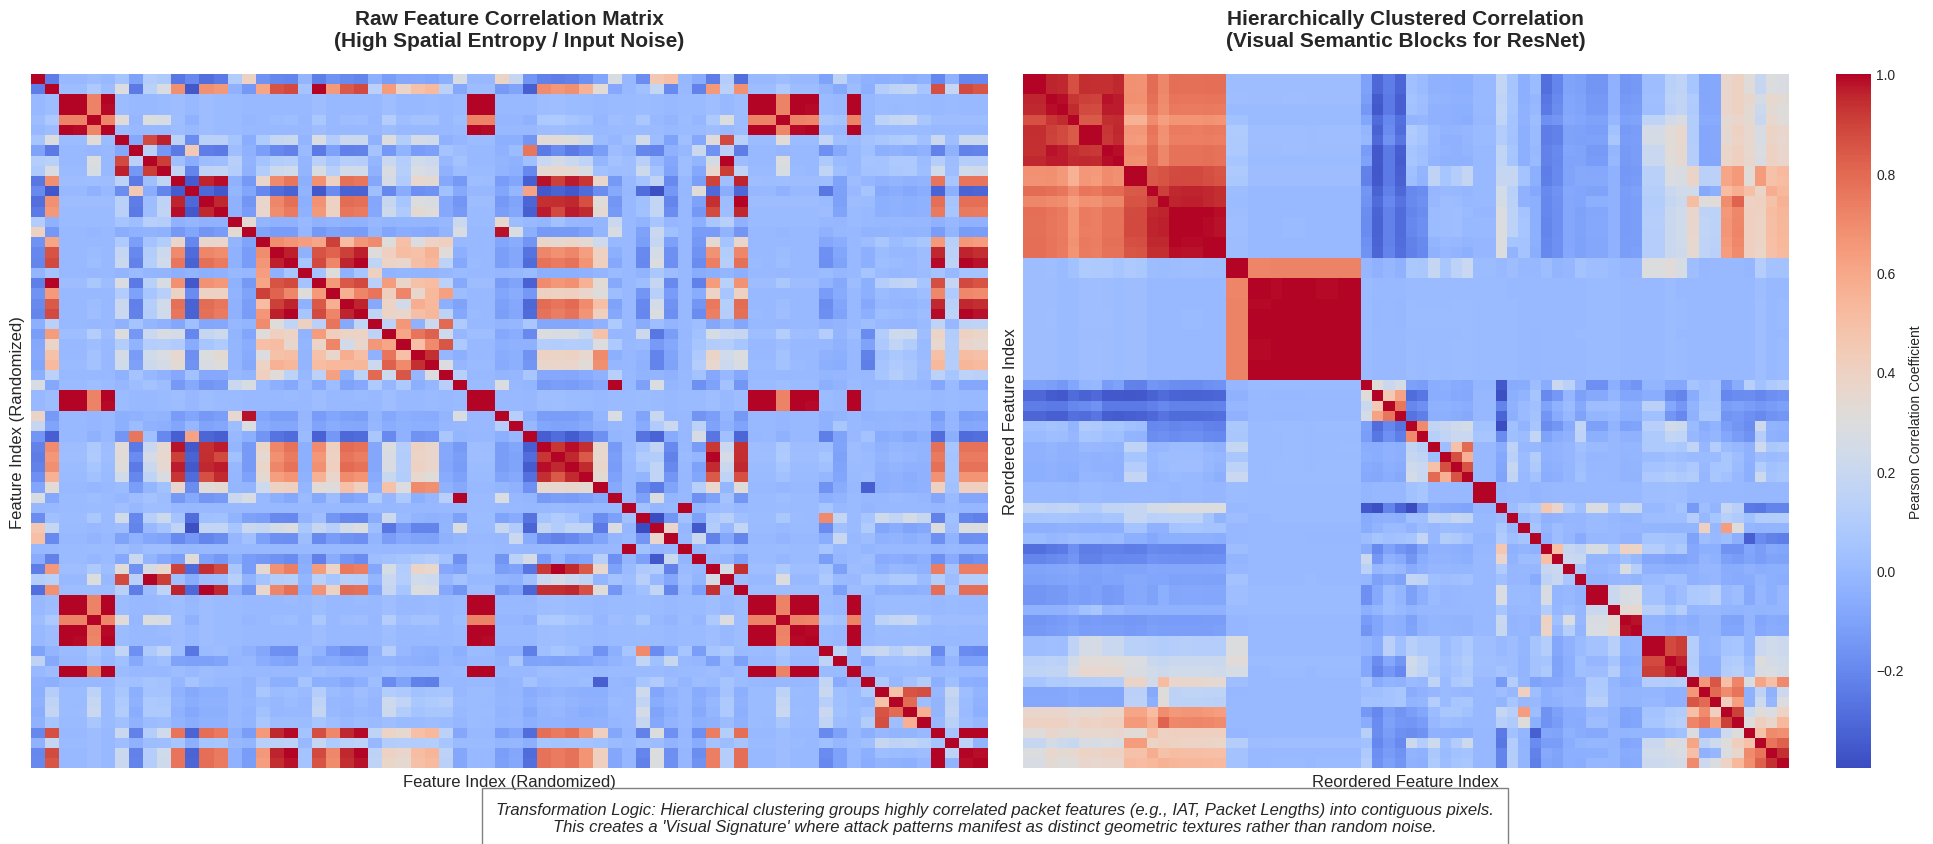

 Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


1025

In [ ]:
print(" Generating Wednesday DoS file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

7. DATA PARTITIONING & CLASS BALANCING (100% SCALE)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(df['Label'])

# Recreate images_9x9 from scaled_vector using the defined generate_9x9_matrix function
images_9x9_current = np.array([generate_9x9_matrix(row) for row in scaled_vector])

# Split data into train and test sets (stratified to maintain class ratios)
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_vector, images_9x9_current, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]

sampler = WeightedRandomSampler(sample_weights, len(y_tr))

train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=128,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on 100% PortScan Scale: {len(y_tr):,} samples.")

✅ Data split complete. Training on 100% PortScan Scale: 488,635 samples.


8. MULTIMODAL ARCHITECTURE & RAM-SAFE DATASET DEFINITION

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import models, transforms

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: ResNet-18 (Pre-trained)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture & Dataset Configured.")

✅ EliteMultimodalResNet Architecture & Dataset Configured.


9. FOCAL LOSS, DEVICE & DIFFERENTIAL OPTIMIZER SETUP

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 5e-5},
    {'params': model.mlp.parameters(), 'lr': 5e-4},
    {'params': model.attention.parameters(), 'lr': 5e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.02)

total_epochs = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3, 1e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

scaler = torch.amp.GradScaler('cuda')
print("✅ Focal Loss and Differential Optimizer ready.")

🚀 Using Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


✅ Focal Loss and Differential Optimizer ready.


10. TRAINING LOOP WITH MACRO-F1 CHECKPOINTING

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import copy

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training 100% PortScan Scale ({len(y_tr):,} samples) for 10 Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Best weights restored.")

🚀 Training 100% PortScan Scale (488,635 samples) for 10 Epochs...


Epoch 1/10: 100%|██████████| 3818/3818 [10:07<00:00,  6.29it/s, loss=0.0004]



📊 [Epoch 1] Train Loss: 0.2846 | Val Acc: 0.9981 | Macro F1: 0.9937
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/10: 100%|██████████| 3818/3818 [13:26<00:00,  4.73it/s, loss=0.2202]



📊 [Epoch 2] Train Loss: 0.0458 | Val Acc: 0.9982 | Macro F1: 0.9938
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


...


📊 [Epoch 8] Train Loss: 0.0170 | Val Acc: 0.9992 | Macro F1: 0.9952


Epoch 9/10: 100%|██████████| 3818/3818 [11:43<00:00,  5.43it/s, loss=0.0011]



📊 [Epoch 9] Train Loss: 0.0140 | Val Acc: 0.9991 | Macro F1: 0.9944


Epoch 10/10: 100%|██████████| 3818/3818 [13:23<00:00,  4.75it/s, loss=0.0163]



📊 [Epoch 10] Train Loss: 0.0150 | Val Acc: 0.9992 | Macro F1: 0.9957
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed

🏁 Training complete. Best weights restored.


11. HIGH-FIDELITY EVALUATION & METRICS SUITE

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

🔍 Final Evaluation: 100%|██████████| 955/955 [03:25<00:00,  4.65it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% PortScan Scale)
OVERALL ACCURACY:  99.9190%
MACRO PRECISION:   0.9928
MACRO RECALL:      0.9986
MACRO F1-SCORE:    0.9957


,precision,recall,f1-score
BENIGN,1.0000,0.9993,0.9996
DoS GoldenEye,0.9823,1.0000,0.9911
DoS Hulk,0.9991,0.9990,0.9990
DoS Slowhttptest,0.9877,0.9981,0.9929
DoS slowloris,0.9880,0.9954,0.9917
Heartbleed,1.0000,1.0000,1.0000


12. MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE

📈 Searching for correct class representatives at 100% PortScan Scale...

############################################################
# SOC ANALYST INTELLIGENCE: BENIGN
############################################################


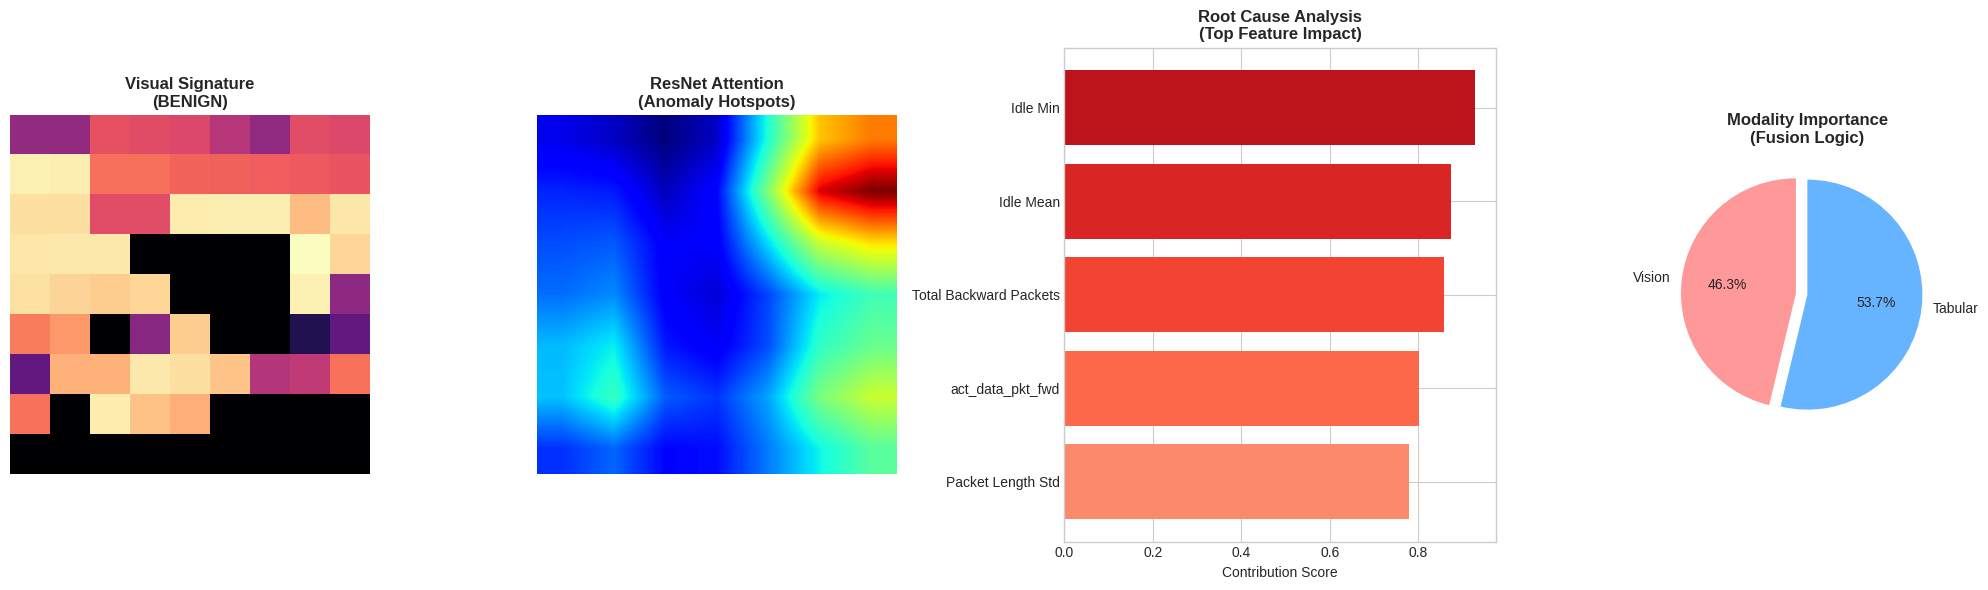

⚠️ No correct prediction found for DoS GoldenEye in current test sample.
⚠️ No correct prediction found for DoS Hulk in current test sample.
⚠️ No correct prediction found for DoS Slowhttptest in current test sample.
⚠️ No correct prediction found for DoS slowloris in current test sample.
⚠️ No correct prediction found for Heartbleed in current test sample.


In [ ]:
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, spatial_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(spatial_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Visual Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Anomaly Hotspots)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [X_filtered.columns[spatial_order[i]] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
    ax2.barh(feat_names[::-1], feat_scores[::-1], color=colors)
    ax2.set_title("Root Cause Analysis\n(Top Feature Impact)", fontweight='bold')
    ax2.set_xlabel("Contribution Score")

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
    ax3.set_title("Modality Importance\n(Fusion Logic)", fontweight='bold')

    plt.tight_layout()
    plt.show()

print("📈 Searching for correct class representatives at 100% PortScan Scale...")

y_te_names = le.inverse_transform(y_te)
class_indices = {}

model.eval()
with torch.no_grad():
    for i in range(len(y_te)):
        t = torch.FloatTensor(X_t_te[i]).unsqueeze(0).to(device)
        img = torch.FloatTensor(X_i_te[i]).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        img = F.interpolate(img, size=(224, 224), mode='nearest').to(device)

        pred = torch.argmax(model(t, img), dim=1).item()
        if pred == y_te[i]:
            class_name = le.classes_[pred]
            if class_name not in class_indices:
                class_indices[class_name] = i
        if len(class_indices) == len(le.classes_):
            break

for attack in le.classes_:
    if attack in class_indices:
        print(f"\n{'#'*60}\n# SOC ANALYST INTELLIGENCE: {attack.upper()}\n{'#'*60}")
        generate_soc_report(class_indices[attack], attack, model, le, X_t_te, X_i_te, X_filtered, spatial_order)
    else:
        print(f"⚠️ No correct prediction found for {attack} in current test sample.")